# Adult Income Prediction — ML Project (Deployment-Ready)

This notebook builds a classification pipeline to predict whether a person's **annual income** (`income`) is above or below **$50K**, based on census attributes (age, education, occupation, hours worked, etc.).

This version of the notebook is written to be **deployment-ready**: every preprocessing step (imputation, encoding, scaling) is **fit only on the training split** and immediately persisted with `joblib`, so the exact same transformations can be replayed on a single new row of raw input at inference time (e.g. from a Streamlit form). The final section reconstructs that inference path end-to-end as a sanity check.

## 1. Import Libraries

In [1]:
from functools import partial
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer

from sklearn.preprocessing import (
    LabelEncoder,
    OrdinalEncoder,
    LabelBinarizer,
    OneHotEncoder,
    MinMaxScaler,
    StandardScaler,
    PowerTransformer,
    RobustScaler,
    label_binarize,
    PolynomialFeatures
)

from category_encoders import TargetEncoder

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold,
    cross_val_score
)

from sklearn.linear_model import (
    LinearRegression,
    Lasso,
    Ridge
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    balanced_accuracy_score,
    roc_auc_score,
    roc_curve,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    auc,
    average_precision_score,
    precision_recall_curve,
    make_scorer,
    ConfusionMatrixDisplay
)

from sklearn.neighbors import (
    KNeighborsRegressor,
    KNeighborsClassifier
)

from sklearn.naive_bayes import (
    GaussianNB,
    ComplementNB,
    MultinomialNB,
    CategoricalNB,
    BernoulliNB
)

from sklearn.tree import (
    DecisionTreeClassifier,
    plot_tree
)

from sklearn.ensemble import (
    RandomForestClassifier,
    BaggingClassifier,
    ExtraTreesClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier,
    VotingClassifier,
    StackingClassifier
)

from sklearn.feature_selection import (
    RFE,
    SelectKBest,
    chi2,
    f_classif,
    f_oneway,
    f_regression,
    mutual_info_classif,
    mutual_info_regression
)

from sklearn.svm import SVC

from sklearn.experimental import enable_hist_gradient_boosting

from sklearn.base import clone

from xgboost import XGBClassifier
import xgboost as xgb

from catboost import CatBoostClassifier

from lightgbm import LGBMClassifier
import lightgbm as lgb

from tqdm import tqdm

from plotly.subplots import make_subplots
import plotly.graph_objects as go
import plotly.express as px

import joblib
import pickle
import math
import os
import tensorflow as tf
import csv
import re

from datetime import datetime

from sklearn.datasets import load_digits

d:\saifproject\.venv\lib\site-packages\sklearn\experimental\enable_hist_gradient_boosting.py:18: UserWarning: Since version 1.0, it is not needed to import enable_hist_gradient_boosting anymore. HistGradientBoostingClassifier and HistGradientBoostingRegressor are now stable and can be normally imported from sklearn.ensemble.
  warnings.warn(


**Interpretation:** All libraries required for data manipulation (`pandas`, `numpy`), visualization (`matplotlib`, `seaborn`, `plotly`), preprocessing (`sklearn.preprocessing`, `sklearn.impute`, `category_encoders`), feature selection, and the classification models compared later (linear, instance-based, tree ensembles, boosting libraries) are imported here. `joblib` is imported specifically so every fitted preprocessing object (imputers, encoders, scaler) and the final model can be persisted for deployment, exactly as in Section 9 onward.

## 2. Load Dataset & Data Dictionary

In [2]:
df = pd.read_csv(r'D:\saifproject\SIC AI\Adult\adult.csv')
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


The raw dataset `adult.csv` (the classic **UCI Adult / Census Income** dataset) is loaded into `df`. Each row represents one individual from the census extraction, with demographic and employment attributes and a binary income label.

### Data Dictionary

| Column | Description |
|---|---|
| `age` | Age of the individual (years) |
| `workclass` | Type of employer (Private, Self-employed, Government, Without-pay, etc.) |
| `fnlwgt` | Census sampling weight — not a property of the individual, dropped during cleaning |
| `education` | Highest education level attained (text label) |
| `education.num` | Highest education level attained, encoded as an ordinal number |
| `marital.status` | Marital status |
| `occupation` | Occupation category |
| `relationship` | Relationship role within the household |
| `race` | Race category |
| `sex` | Sex (Male / Female) |
| `capital.gain` | Capital gains reported |
| `capital.loss` | Capital losses reported |
| `hours.per.week` | Average hours worked per week |
| `native.country` | Country of origin |
| `income` | **Target.** Whether annual income is `<=50K` or `>50K` |

Missing values in the raw file are encoded as the literal string `"?"` rather than a true `NaN`, which is corrected in the next section before any missing-value analysis.

## 3. Initial Data Inspection

A first, read-only look at the raw dataset: shape, dtypes, missing values, and summary statistics. The only change made in this section is converting the `"?"` placeholder to a real `NaN` so missingness can actually be measured — no rows or columns are modified or dropped yet (that happens in the next section).

In [3]:
df.replace('?', np.nan, inplace=True)

**Interpretation:** The raw file encodes missing values as the string `"?"`. Replacing it with `np.nan` up front means `df.isnull()`, `df.info()`, and every downstream missing-value check reflect the true amount of missing data instead of silently treating `"?"` as a valid category.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       30725 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      30718 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  31978 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


**Interpretation:** `df.info()` shows 32,561 rows across 15 columns. `age`, `fnlwgt`, `education.num`, `capital.gain`, `capital.loss`, and `hours.per.week` are numeric; the remaining columns (`workclass`, `education`, `marital.status`, `occupation`, `relationship`, `race`, `sex`, `native.country`, `income`) are text/categorical, matching the data dictionary above.

In [5]:
missing_count = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Column': df.columns,
    'Missing Values': missing_count.values,
    'Missing Percentage (%)': missing_percent.values
}).sort_values(by='Missing Percentage (%)', ascending=False).reset_index(drop=True)
display(missing_df)

,Column,Missing Values,Missing Percentage (%)
0,occupation,1843,5.660146
1,workclass,1836,5.638647
2,native.country,583,1.790486
3,fnlwgt,0,0.000000
4,education,0,0.000000
5,education.num,0,0.000000
6,age,0,0.000000
7,marital.status,0,0.000000
8,relationship,0,0.000000
9,sex,0,0.000000


**Interpretation:** Only a handful of columns carry missing values once `"?"` is converted to `NaN` — `occupation`, `workclass`, and `native.country`. None of the affected columns are missing more than a few percent of rows, so imputation (rather than dropping the column) is the right approach; this is handled later, on the training split only, in Section 9.

C:\Users\Saif_Alaswad\AppData\Local\Temp\ipykernel_9332\662680555.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


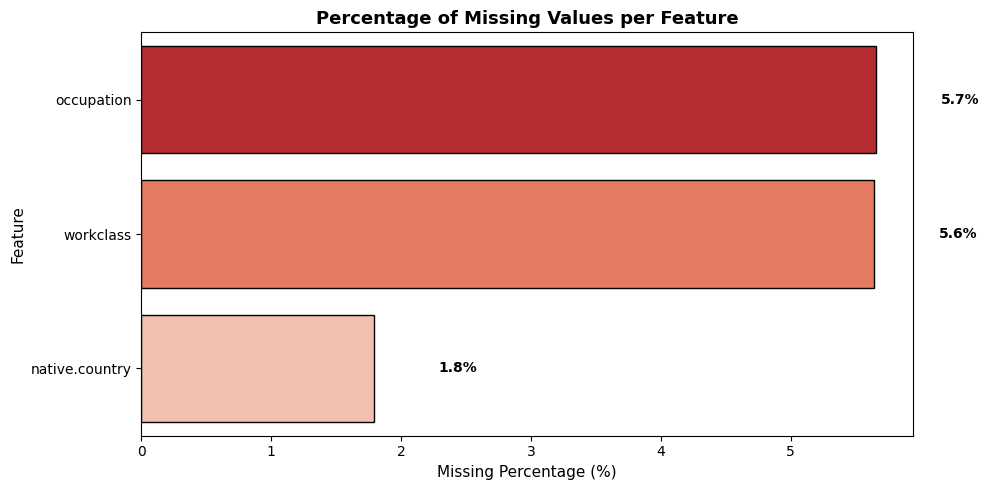

In [6]:
plt.figure(figsize=(10, 5))
cols_with_missing = missing_df[missing_df['Missing Values'] > 0]
sns.barplot(
    data=cols_with_missing,
    x='Missing Percentage (%)',
    y='Column',
    palette='Reds_r',
    edgecolor='black'
)
plt.title('Percentage of Missing Values per Feature', fontsize=13, fontweight='bold')
plt.xlabel('Missing Percentage (%)', fontsize=11)
plt.ylabel('Feature', fontsize=11)

for index, value in enumerate(cols_with_missing['Missing Percentage (%)']):
    plt.text(value + 0.5, index, f"{value:.1f}%", va='center', fontweight='bold')

plt.tight_layout()
plt.show()

**Interpretation:** The bar chart confirms `workclass`, `occupation`, and `native.country` are the only columns with missing data, and each is missing well under 10% of rows — small enough that a simple most-frequent-category imputation (Section 9) is a reasonable, low-risk choice.

In [7]:
df.describe()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


**Interpretation:** `df.describe()` summarizes the numeric columns. `capital.gain` and `capital.loss` are heavily right-skewed (median of 0, but a long tail of large values), and `fnlwgt` is a census sampling weight rather than a real attribute of the individual — both observations are addressed in the cleaning section below.

In [8]:
df.duplicated().sum()

np.int64(24)

**Interpretation:** A non-zero duplicate count confirms some rows are exact repeats of others. These duplicates, along with the other deterministic cleaning steps, are handled in the **Basic Data Cleaning** section below.

## 4. Basic Data Cleaning

This section applies only **deterministic** cleaning rules — steps that do not learn any statistic or mapping from the data and therefore do not require fitting on a training split. This includes: removing duplicates, dropping non-predictive columns, and collapsing high-cardinality categorical columns into a smaller, more meaningful set of categories.

In [9]:
df.drop_duplicates(keep='first', inplace=True)
df.reset_index(drop=True, inplace=True)

**Interpretation:** Exact duplicate rows are removed, since keeping them would let the same record influence both the EDA and model training more than once.

In [10]:
df.drop(['fnlwgt', 'education'], axis=1, inplace=True)

**Interpretation:** `fnlwgt` is a census sampling weight, not a property of the individual, so it carries no predictive signal about their income. `education` is dropped because it is a text duplicate of `education.num`, which already encodes the same information ordinally and is easier for models to use directly — keeping both would just add redundant, encodable text for no benefit.

In [11]:
df.duplicated().sum()

np.int64(3441)

In [12]:
df.drop_duplicates(keep='first', inplace=True)
df.reset_index(drop=True, inplace=True)

**Interpretation:** Dropping `fnlwgt` and `education` can turn previously-distinct rows into duplicates (two people who only differed by sampling weight or by an education label that mapped to the same `education.num` now look identical), so duplicates are checked and removed once more before continuing.

### 4.1 Standardizing categorical text

The raw dataset has several categorical columns with many small, overlapping categories (e.g. dozens of `native.country` values, or five separate "not currently married" categories in `marital.status`). These are consolidated into a smaller, more meaningful set of categories — a purely deterministic, rule-based recoding that doesn't need to be fit on any split.

In [13]:
fig = make_subplots(rows=1, cols=2, subplot_titles=("Unique values per Categorical feature", "Unique values per Numerical feature"))

for col_type, col, color in [("exclude", 1, '#016CC9'), ("include", 2, '#DEB078')]:
    temp_data = df.select_dtypes(**{col_type: "number"}).nunique().sort_values()
    fig.add_trace(go.Bar(x=temp_data.index, y=temp_data.values, marker=dict(color=color)), row=1, col=col)

fig.show()

**Interpretation:** Comparing unique-value counts across categorical vs. numeric columns highlights which categorical features (like `native.country` and `occupation`) have high cardinality and are candidates for consolidation before encoding.

In [14]:
columns = df.select_dtypes(include="object").columns.tolist()

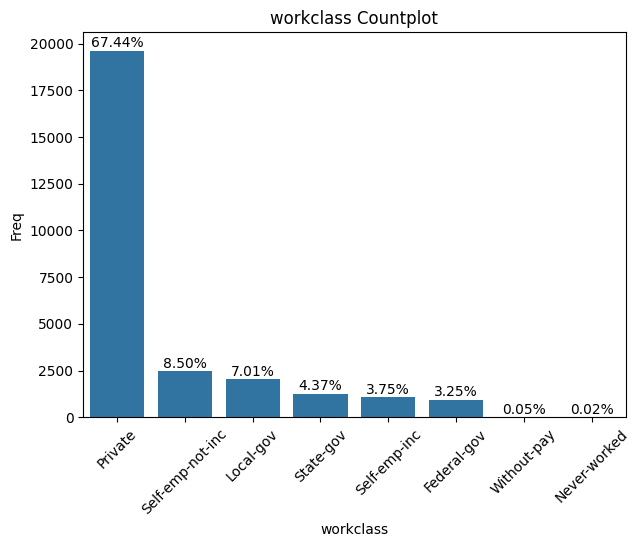

,count,Percentage
workclass,,
Private,19621,67.44
Self-emp-not-inc,2473,8.50
Local-gov,2040,7.01
State-gov,1272,4.37
Self-emp-inc,1091,3.75
Federal-gov,946,3.25
Without-pay,14,0.05
Never-worked,7,0.02


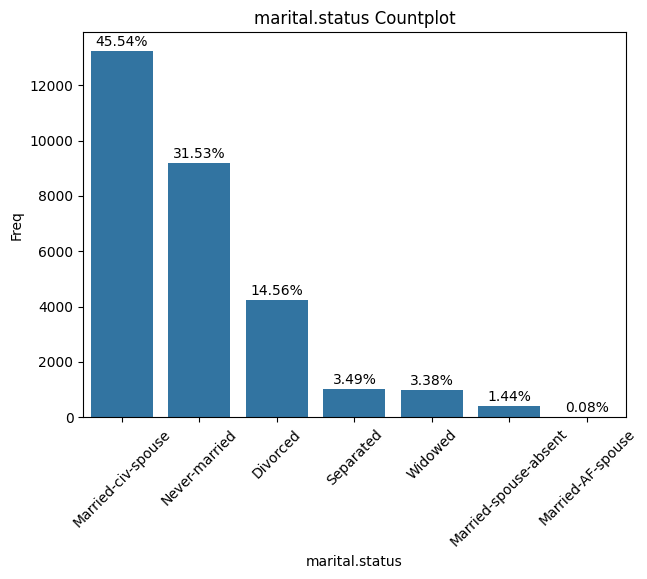

,count,Percentage
marital.status,,
Married-civ-spouse,13249,45.54
Never-married,9173,31.53
Divorced,4237,14.56
Separated,1014,3.49
Widowed,982,3.38
Married-spouse-absent,418,1.44
Married-AF-spouse,23,0.08


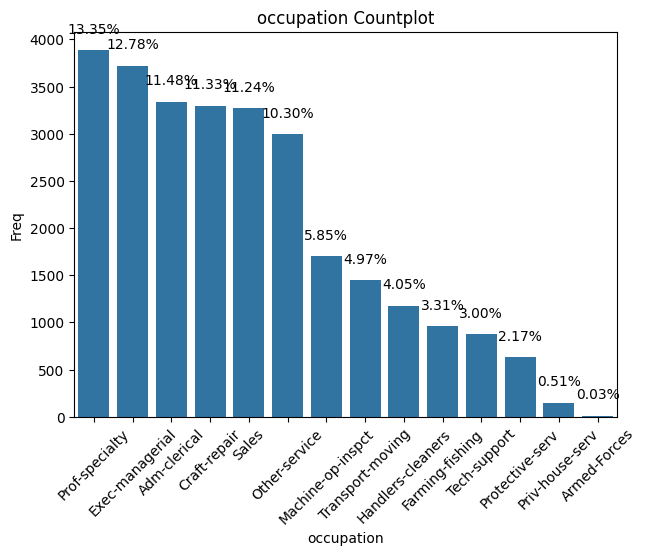

,count,Percentage
occupation,,
Prof-specialty,3885,13.35
Exec-managerial,3719,12.78
Adm-clerical,3340,11.48
Craft-repair,3298,11.33
Sales,3270,11.24
Other-service,2996,10.30
Machine-op-inspct,1702,5.85
Transport-moving,1445,4.97
Handlers-cleaners,1179,4.05


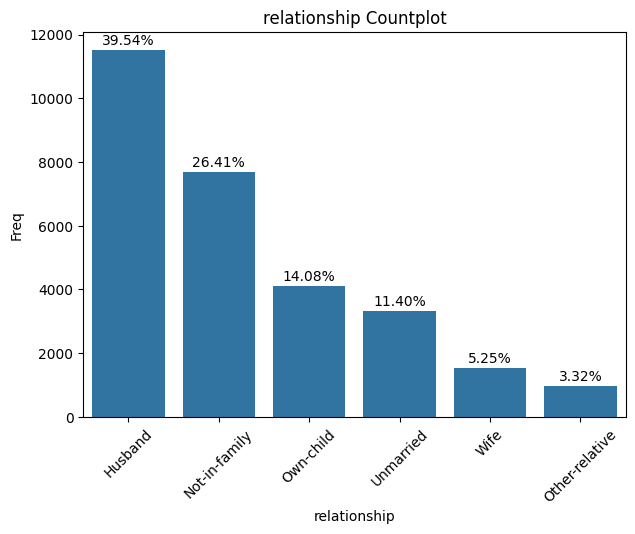

,count,Percentage
relationship,,
Husband,11506,39.54
Not-in-family,7684,26.41
Own-child,4096,14.08
Unmarried,3317,11.40
Wife,1528,5.25
Other-relative,965,3.32


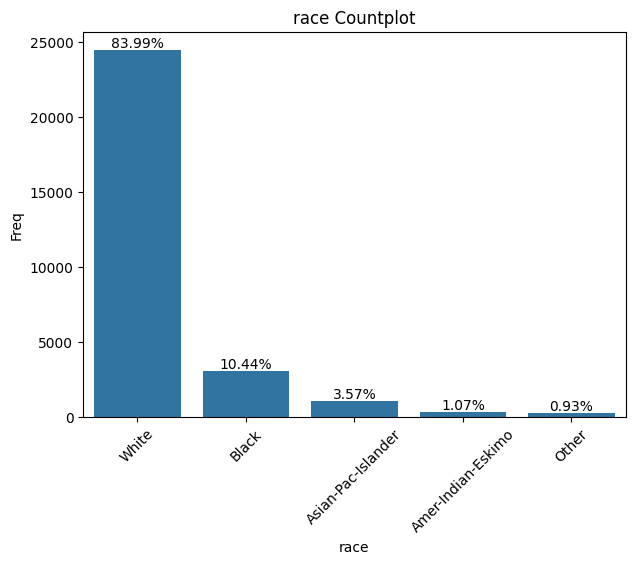

,count,Percentage
race,,
White,24438,83.99
Black,3038,10.44
Asian-Pac-Islander,1038,3.57
Amer-Indian-Eskimo,311,1.07
Other,271,0.93


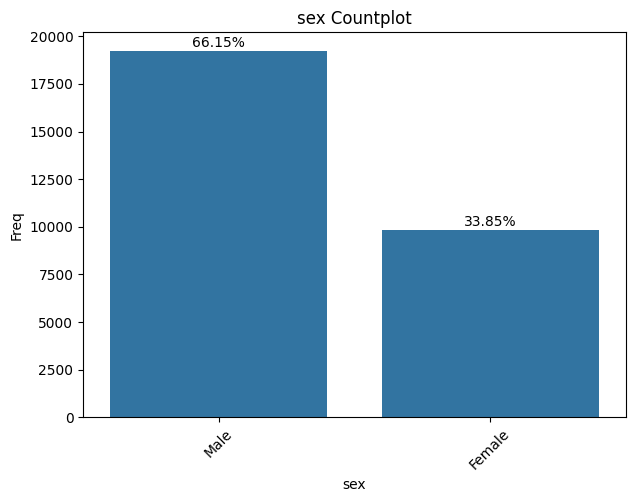

,count,Percentage
sex,,
Male,19246,66.15
Female,9850,33.85


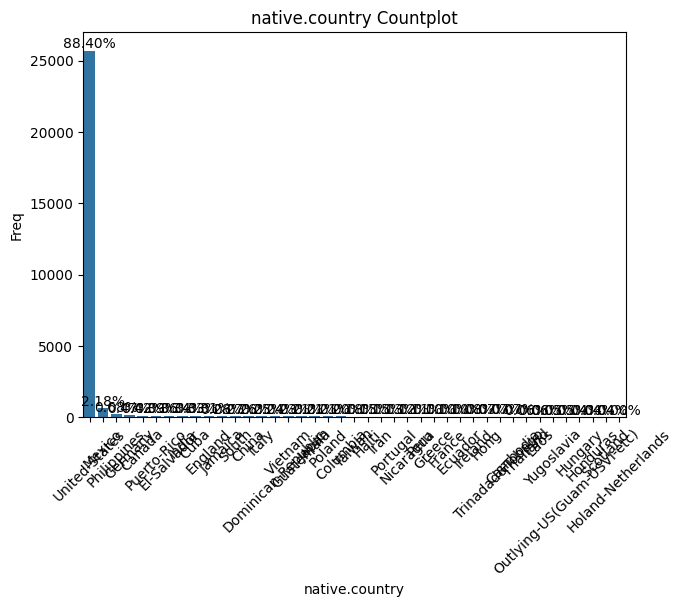

,count,Percentage
native.country,,
United-States,25721,88.40
Mexico,633,2.18
Philippines,198,0.68
Germany,137,0.47
Canada,121,0.42
Puerto-Rico,114,0.39
El-Salvador,106,0.36
India,100,0.34
Cuba,95,0.33


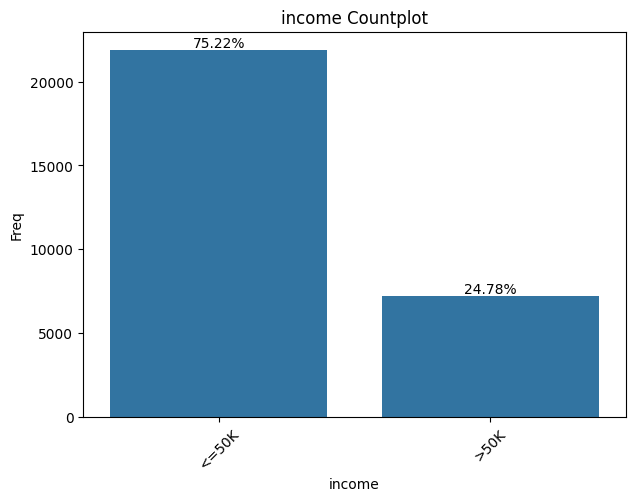

,count,Percentage
income,,
<=50K,21886,75.22
>50K,7210,24.78


In [15]:
for col in columns:
    work_values = df[col].value_counts()
    plt.figure(figsize=(7, 5))
    plt.title(f"{col} Countplot")
    sns.countplot(data=df, x=col, order=work_values.index)
    plt.xlabel(col)
    plt.ylabel("Freq")
    plt.tick_params(axis='x', labelrotation=45)
    for idx in range(len(work_values)):
        text = f"{work_values.values[idx] * 100 / len(df):.2f}%"
        plt.text(x=idx, y=work_values.values[idx] + 180, s=text, ha='center')
    plt.show()
    freq = pd.DataFrame(work_values)
    freq["Percentage"] = round(freq["count"] * 100 / len(df), 2)
    display(freq)

**Interpretation:** These per-column countplots make the imbalance in each categorical feature explicit — e.g. `native.country` is overwhelmingly `United-States`, and `race` is dominated by one category — which directly motivates the consolidation rules applied next.

In [16]:
df['race'] = df['race'].replace(['Asian-Pac-Islander', 'Amer-Indian-Eskimo', 'Other'], 'Others')

In [91]:
df['occupation'].value_counts()

occupation
Prof-specialty       3820
Exec-managerial      3665
Sales                3228
Craft-repair         3206
Adm-clerical         3201
Other-service        2934
Machine-op-inspct    1661
Transport-moving     1434
Handlers-cleaners    1158
Farming-fishing       955
Tech-support          871
Protective-serv       621
Priv-house-serv       147
Armed-Forces            9
Name: count, dtype: int64

**Interpretation:** The smaller `race` categories are grouped into a single `Others` bucket. Each of them individually has very few observations, so keeping them separate would only add sparse, noisy categories to the model without adding real signal.

In [17]:
df['marital.status'] = df['marital.status'].replace(
    ['Widowed', 'Divorced', 'Separated', 'Never-married'], 'not_married')
df['marital.status'] = df['marital.status'].replace(
    ['Married-civ-spouse', 'Married-spouse-absent', 'Married-AF-spouse'], 'married')

**Interpretation:** `marital.status` originally has seven overlapping categories describing essentially two states — currently married or not — so they are collapsed into `married` / `not_married`. This keeps the feature simple and avoids splitting the signal across many rare categories.

In [18]:
work_class = {
    'Self-emp-inc': 'Self-employed',
    'Self-emp-not-inc': 'Self-employed',
    'State-gov': 'Government',
    'Federal-gov': 'Government',
    'Local-gov': 'Government',
    'Without-pay': 'Without-pay'}
df['workclass'] = df['workclass'].replace(work_class)

**Interpretation:** `workclass` categories that describe the same broad employer type (e.g. the three government levels, or the two self-employment types) are merged, reducing the number of one-hot columns created later without losing the meaningful distinction between employer types (private, self-employed, government, without pay).

In [19]:
df.loc[
    df['native.country'].notna() &
    (df['native.country'] != 'United-States'),
    'native.country'
] = 'Others'

**Interpretation:** `native.country` has dozens of categories, almost all with very few observations, and the countplot above showed the dataset is overwhelmingly `United-States`. Collapsing everything else into `Others` turns this into a clean, low-cardinality binary-style feature instead of a sparse one-hot block with many near-empty columns.

In [20]:
df.isna().sum().sort_values(ascending=False)

occupation        1639
workclass         1632
native.country     580
education.num        0
age                  0
marital.status       0
relationship         0
sex                  0
race                 0
capital.gain         0
capital.loss         0
hours.per.week       0
income               0
dtype: int64

**Interpretation:** This reflects the missing-value state after cleaning: `occupation`, `workclass`, and `native.country` still carry the same small amount of missingness noted in Section 3 — the consolidation steps above only recoded existing categories and did not introduce or remove any missing values. These remaining gaps are intentionally left for the imputation step later in the modeling pipeline, so the same fitted imputer used here can be reapplied to any new single-row input at inference time.

This closes the deterministic cleaning stage. A small reusable function captures every rule above so it can be replayed later on a single raw row at inference time.

In [21]:
def apply_basic_cleaning(df_raw, is_training=False):
    d = df_raw.copy()
    d.replace('?', np.nan, inplace=True)

    if is_training:
        d.drop_duplicates(keep='first', inplace=True)
        d.reset_index(drop=True, inplace=True)

    for col in ['fnlwgt', 'education']:
        if col in d.columns:
            d.drop(columns=[col], inplace=True)

    if is_training:
        d.drop_duplicates(keep='first', inplace=True)
        d.reset_index(drop=True, inplace=True)

    if 'race' in d.columns:
        d['race'] = d['race'].replace(['Asian-Pac-Islander', 'Amer-Indian-Eskimo', 'Other'], 'Others')

    if 'marital.status' in d.columns:
        d['marital.status'] = d['marital.status'].replace(
            ['Widowed', 'Divorced', 'Separated', 'Never-married'], 'not_married')
        d['marital.status'] = d['marital.status'].replace(
            ['Married-civ-spouse', 'Married-spouse-absent', 'Married-AF-spouse'], 'married')

    if 'workclass' in d.columns:
        work_class = {
            'Self-emp-inc': 'Self-employed',
            'Self-emp-not-inc': 'Self-employed',
            'State-gov': 'Government',
            'Federal-gov': 'Government',
            'Local-gov': 'Government',
            'Without-pay': 'Without-pay'}
        d['workclass'] = d['workclass'].replace(work_class)

    if 'native.country' in d.columns:
        d.loc[
            d['native.country'].notna() &
            (d['native.country'] != 'United-States'),
            'native.country'
        ] = 'Others'

    return d

**Verification:** this function is not re-run over the training `df` above (that would duplicate transformations unnecessarily) — it is only exercised later, in the final deployment simulation, to confirm it reproduces the same result as the manual steps performed above.

## 5. Exploratory Data Analysis (EDA)

The cleaned dataset is now explored visually to understand feature distributions, relationships with the target (`income`), and correlations between features. Nothing in this section is used by the deployment pipeline — it is purely for understanding the data before modeling.

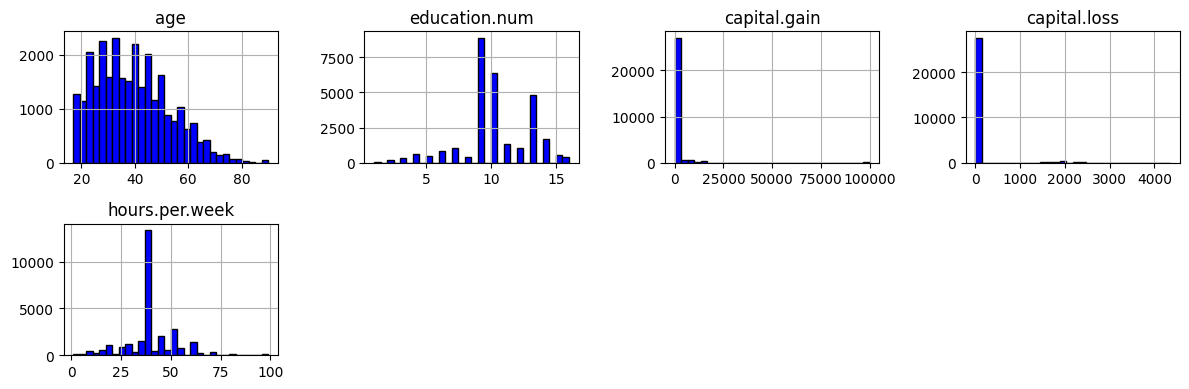

In [22]:
figsize_val = (12, 4)
layout_val = (-1, 4)
df.hist(bins=30, figsize=figsize_val, layout=layout_val, edgecolor="black", color='blue')
plt.tight_layout()

**Interpretation:** The histograms of numeric features show `age` and `hours.per.week` roughly centered with some skew, while `capital.gain` and `capital.loss` are extremely right-skewed with most values at zero — a pattern typical of financial variables where most people report nothing and a small minority report large amounts.

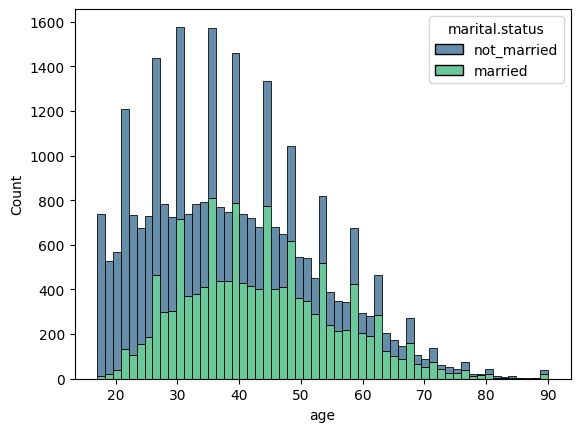

In [23]:
sns.histplot(data=df, x='age', hue='marital.status', multiple='stack', palette='viridis');

**Interpretation:** Splitting the `age` distribution by `marital.status` shows married individuals skew older on average than not-married individuals, consistent with marriage patterns over a working lifetime.

C:\Users\Saif_Alaswad\AppData\Local\Temp\ipykernel_9332\640899598.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y='occupation', x='age', data=df, order=df['occupation'].value_counts().index, palette='viridis');


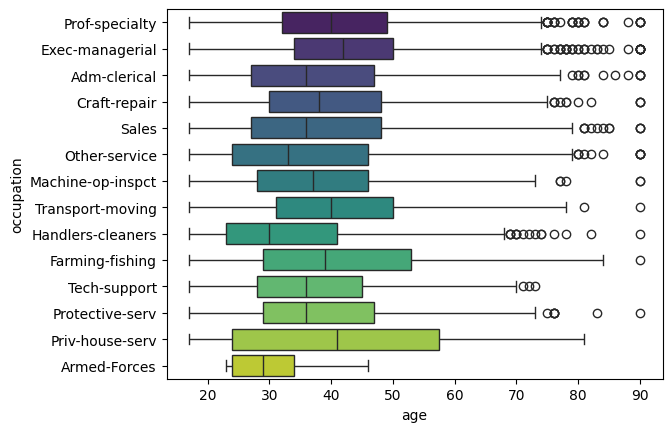

In [24]:
sns.boxplot(y='occupation', x='age', data=df, order=df['occupation'].value_counts().index, palette='viridis');

**Interpretation:** Age varies noticeably by occupation — some occupations (e.g. executive/managerial roles) skew toward older workers, while others skew younger, which is useful context for interpreting `occupation`'s relationship with income later.

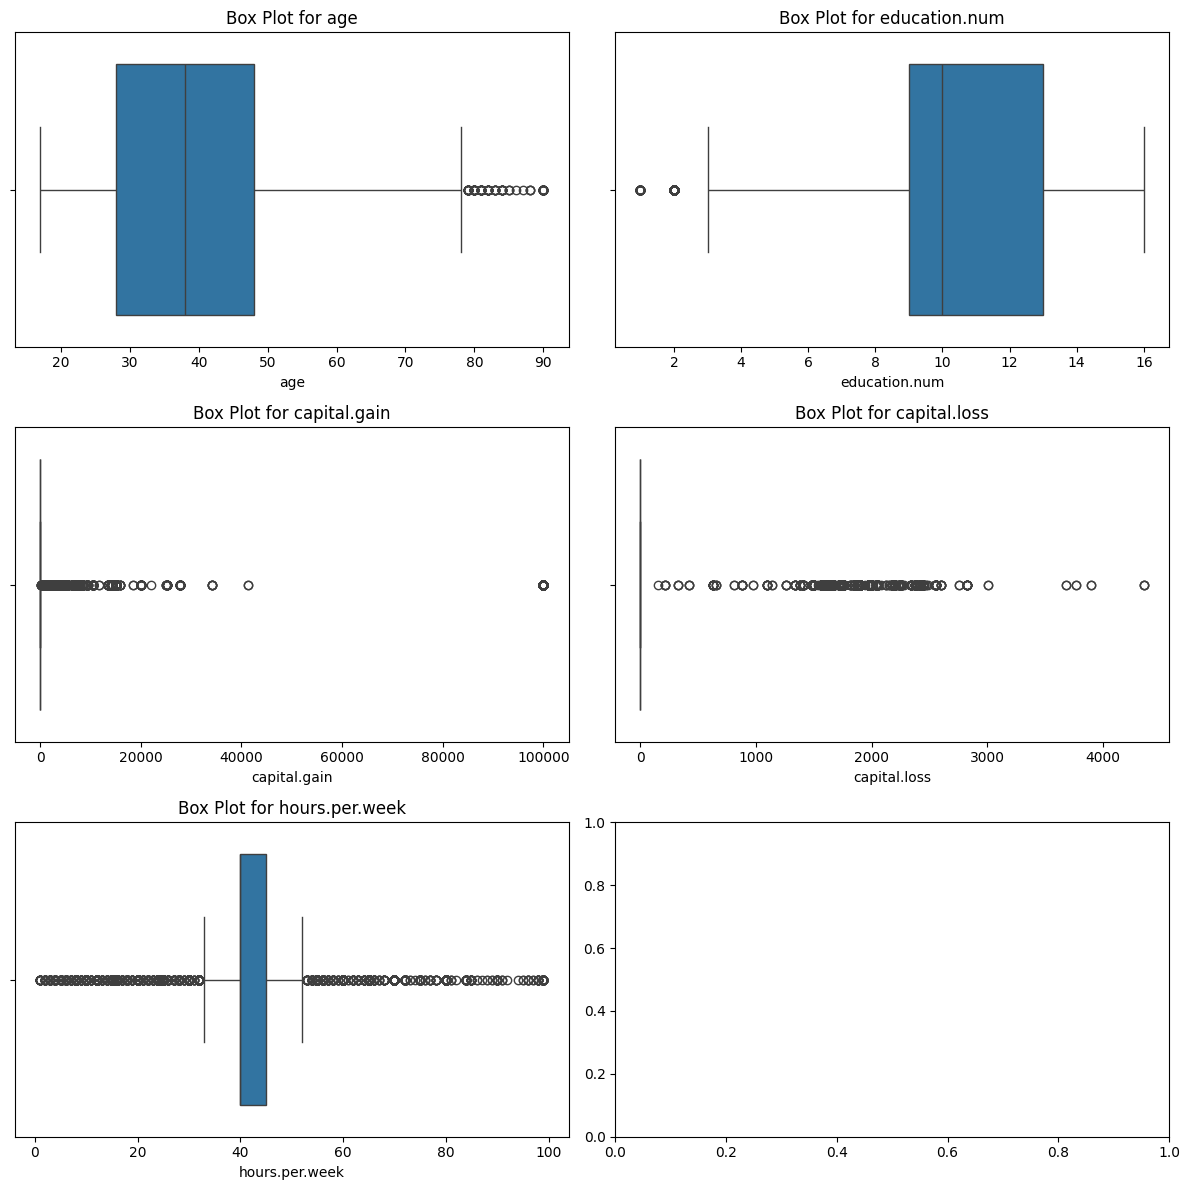

In [25]:
numeric_cols = ['age', 'education.num', 'capital.gain', 'capital.loss', 'hours.per.week']
fig, axes = plt.subplots(3, 2, figsize=(12, 12))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(f'Box Plot for {col}')
plt.tight_layout()
plt.show()

**Interpretation:** The box plots make the skew in `capital.gain` and `capital.loss` very visible (almost all mass at zero with extreme outliers), while `age`, `education.num`, and `hours.per.week` are much better behaved — reinforcing that scaling method choice later should be robust to outliers.

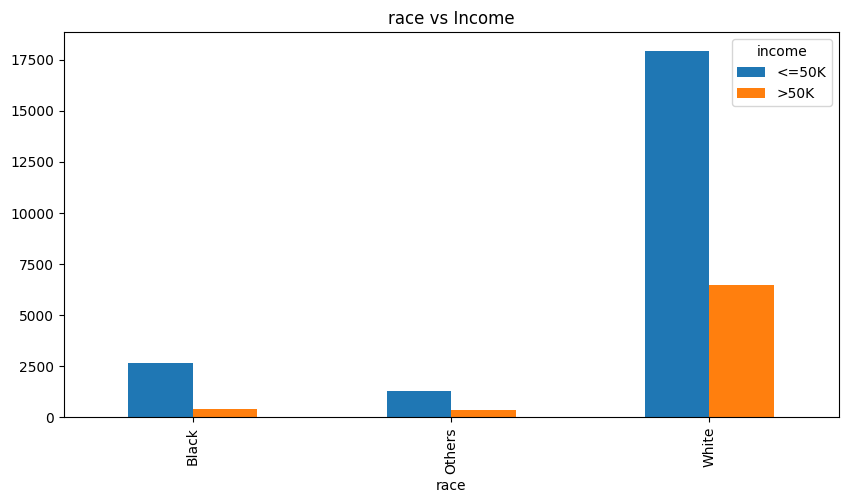

In [26]:
top_countries = df['race'].value_counts().head(10).index
pd.crosstab(df[df['race'].isin(top_countries)]['race'],
            df['income']).plot(kind='bar', figsize=(10, 5))
plt.title('race vs Income')
plt.show()

**Interpretation:** The high-income share differs somewhat across `race` categories, though the category sizes are very unequal (as seen in Section 4's countplots), so this difference should be read alongside that imbalance rather than as a strong standalone signal.

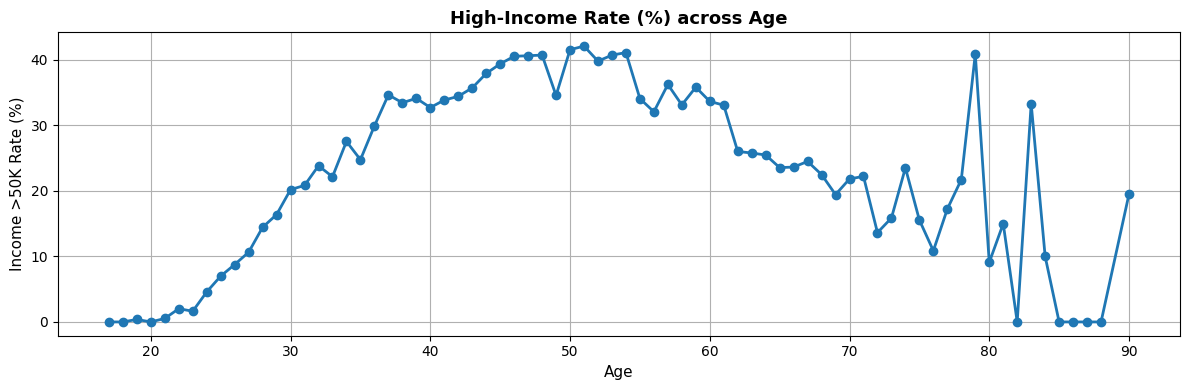

In [27]:
exp_target = (
    df.groupby('age')['income']
    .apply(lambda x: (x == '>50K').mean())
    .reset_index(name='income_rate')
)

exp_target['income_rate'] = exp_target['income_rate'] * 100

plt.figure(figsize=(12, 4))

plt.plot(
    exp_target['age'],
    exp_target['income_rate'],
    marker='o',
    linewidth=2
)

plt.title(
    'High-Income Rate (%) across Age',
    fontweight='bold',
    fontsize=13
)

plt.xlabel('Age', fontsize=11)
plt.ylabel('Income >50K Rate (%)', fontsize=11)

plt.grid(True)
plt.tight_layout()
plt.show()

**Interpretation:** The high-income rate rises with age through the prime working years and then declines for the oldest ages, an intuitive lifecycle pattern (career progression followed by retirement/reduced hours) that suggests `age` alone is not linearly related to income and may benefit tree-based models that can capture this non-monotonic shape.

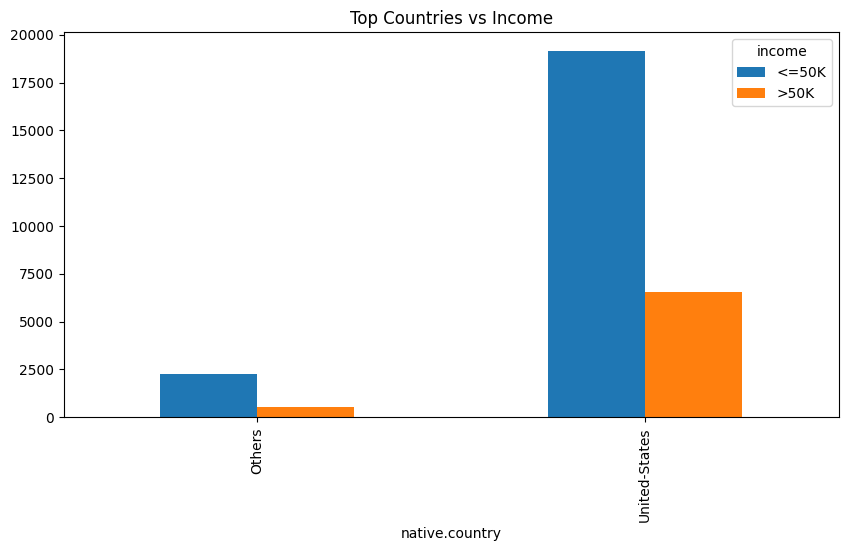

In [28]:
top_countries = df['native.country'].value_counts().head(10).index
pd.crosstab(df[df['native.country'].isin(top_countries)]['native.country'],
            df['income']).plot(kind='bar', figsize=(10, 5))
plt.title('Top Countries vs Income')
plt.show()

**Interpretation:** Since `native.country` was consolidated into `United-States` vs. `Others` in Section 4, this chart is dominated by the `United-States` bar, with income patterns for the collapsed `Others` group visible as a smaller comparison bar.

In [29]:
px.histogram(
    df,
    x='marital.status',
    color='income',
    barmode='group',
    color_discrete_sequence=['blue', 'orange']
)

**Interpretation:** `married` individuals show a noticeably higher share of `>50K` earners than `not_married` individuals, making `marital.status` one of the more visually distinctive predictors in the dataset.

In [30]:
px.histogram(
    df,
    x='education.num',
    color='income',
    barmode='group',
    color_discrete_sequence=['blue', 'orange']
)

**Interpretation:** The share of `>50K` earners rises steadily with `education.num`, confirming education level as one of the clearest, most monotonic predictors of income in this dataset.

In [31]:
px.histogram(
    df,
    x='workclass',
    color='income',
    barmode='group',
    color_discrete_sequence=['blue', 'orange']
)

**Interpretation:** Self-employed (incorporated) and government workers show relatively higher `>50K` shares than private-sector or without-pay workers, though `Private` remains by far the largest category by volume.

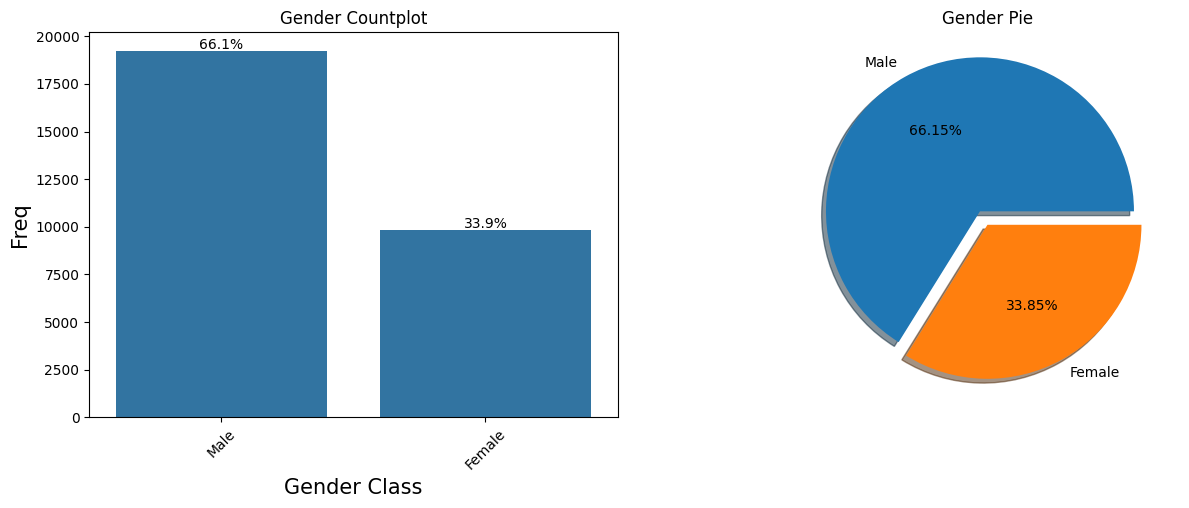

,count,Percentage
sex,,
Male,19246,66.15
Female,9850,33.85


In [32]:
gender_values = df.sex.value_counts()
fig, axis = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))
axis[0].set_title("Gender Countplot")
sns.countplot(data=df, x="sex", order=gender_values.index, ax=axis[0])
axis[0].set_xlabel("Gender Class", fontsize=15)
axis[0].set_ylabel("Freq", fontsize=15)
axis[0].tick_params(axis='x', labelrotation=45)
for idx in range(len(gender_values)):
    text = f"{gender_values.values[idx]*100/len(df):.1f}%"
    axis[0].text(x=idx, y=gender_values.values[idx]+100, s=text, fontsize=10, ha='center')
axis[1].pie(gender_values.values, labels=gender_values.index, autopct="%.2f%%", explode=[0.1, 0], shadow=True)
axis[1].set_title("Gender Pie")
plt.show()
freq = pd.DataFrame(gender_values)
freq["Percentage"] = round(freq['count']*100/len(df), 2)
display(freq)

**Interpretation:** The dataset skews roughly two-thirds male, which is worth keeping in mind when interpreting `sex`-related patterns since the two groups are not equally represented.

In [33]:
px.histogram(
    df,
    x='sex',
    color='income',
    barmode='group',
    color_discrete_sequence=['blue', 'orange']
)

**Interpretation:** The share of `>50K` earners is visibly higher among males than females in this dataset, making `sex` another feature with a clear (if socially loaded) relationship to the target.

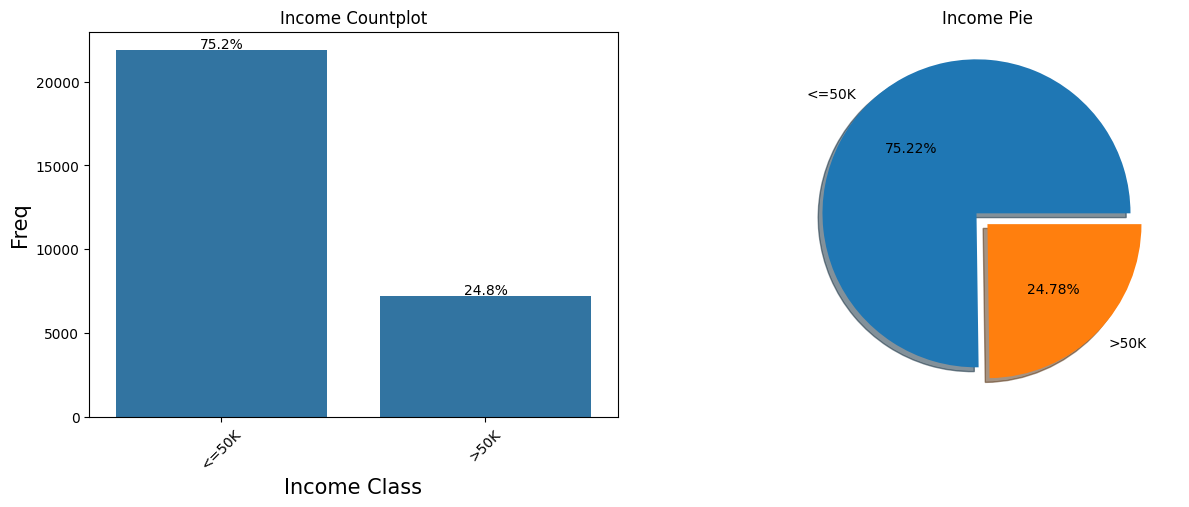

,count,Percentage
income,,
<=50K,21886,75.22
>50K,7210,24.78


In [34]:
gender_values = df.income.value_counts()
fig, axis = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))
axis[0].set_title("Income Countplot")
sns.countplot(data=df, x="income", order=gender_values.index, ax=axis[0])
axis[0].set_xlabel("Income Class", fontsize=15)
axis[0].set_ylabel("Freq", fontsize=15)
axis[0].tick_params(axis='x', labelrotation=45)
for idx in range(len(gender_values)):
    text = f"{gender_values.values[idx]*100/len(df):.1f}%"
    axis[0].text(x=idx, y=gender_values.values[idx]+100, s=text, fontsize=10, ha='center')
axis[1].pie(gender_values.values, labels=gender_values.index, autopct="%.2f%%", explode=[0.1, 0], shadow=True)
axis[1].set_title("Income Pie")
plt.show()
freq = pd.DataFrame(gender_values)
freq["Percentage"] = round(freq['count']*100/len(df), 2)
display(freq)

**Interpretation:** The target class is imbalanced — roughly three-quarters of individuals earn `<=50K` and about a quarter earn `>50K`. This is exactly why every model below is trained with `class_weight='balanced'` (or an equivalent) and evaluated with F1/balanced-accuracy rather than raw accuracy alone.

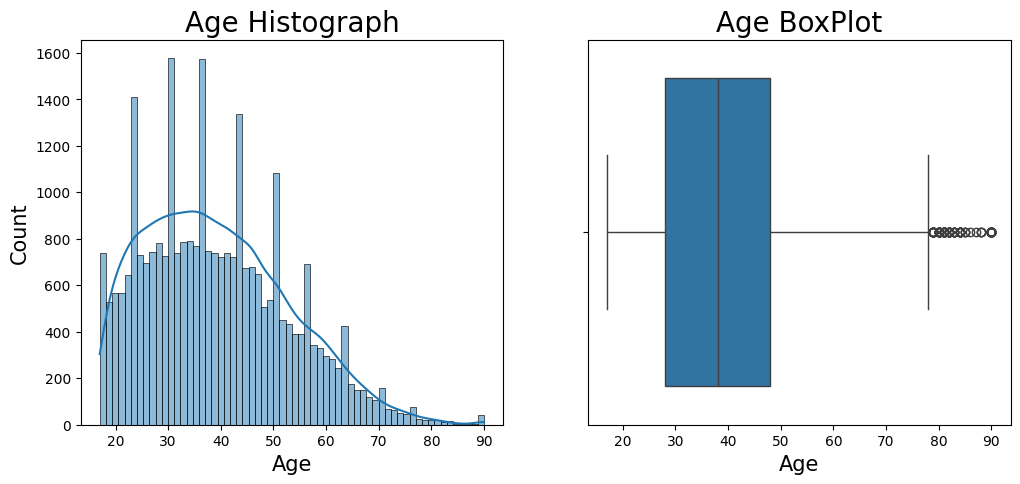

In [35]:
fig, axis = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))
sns.histplot(data=df, x="age", ax=axis[0], bins="rice", kde=True)
axis[0].set_title("Age Histograph", fontsize=20)
axis[0].set_xlabel("Age", fontsize=15)
axis[0].set_ylabel("Count", fontsize=15)
sns.boxplot(data=df, x="age", ax=axis[1])
axis[1].set_title("Age BoxPlot", fontsize=20)
axis[1].set_xlabel("Age", fontsize=15)
plt.show()

**Interpretation:** `age` is right-skewed with most individuals between roughly 25 and 50, and a smaller tail of older workers — the boxplot flags a handful of high-age outliers but nothing implausible for a real population.

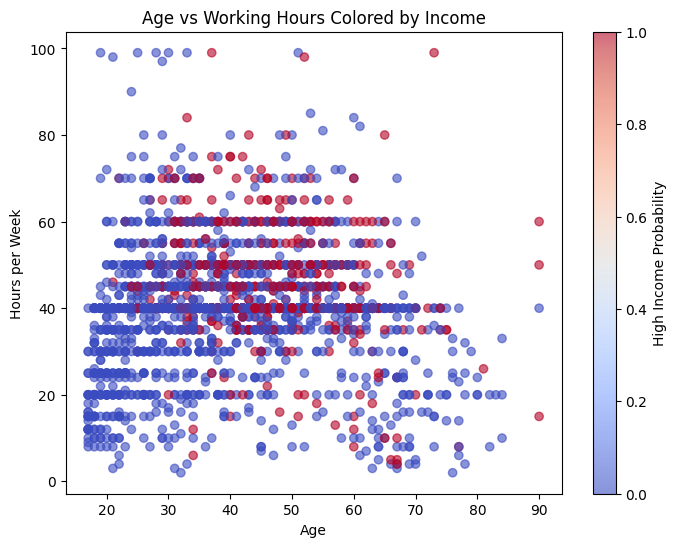

In [36]:
sample_df = df.sample(3000, random_state=42)

plt.figure(figsize=(8, 6))
plt.scatter(
    sample_df["age"],
    sample_df["hours.per.week"],
    c=(sample_df["income"] == ">50K"),
    cmap="coolwarm",
    alpha=0.6
)

plt.colorbar(label="High Income Probability")
plt.title("Age vs Working Hours Colored by Income")
plt.xlabel("Age")
plt.ylabel("Hours per Week")
plt.show()

**Interpretation:** On a 3,000-row sample, `>50K` earners (red) cluster around mid-career ages with higher-than-average weekly hours, while `<=50K` earners (blue) are spread more broadly across ages and hours — suggesting `age` and `hours.per.week` interact rather than acting independently on income.

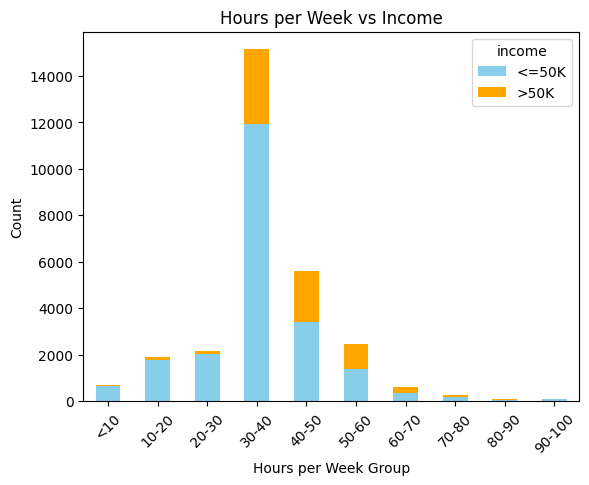

In [37]:
hours_bins = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
hours_labels = ['<10', '10-20', '20-30', '30-40', '40-50', '50-60', '60-70', '70-80', '80-90', '90-100']
hours_income = pd.crosstab(
    df['income'],
    pd.cut(df['hours.per.week'], bins=hours_bins, labels=hours_labels)
)
hours_income.T.plot(kind='bar', stacked=True, color=['skyblue', 'orange'])
plt.title("Hours per Week vs Income")
plt.xlabel("Hours per Week Group")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

**Interpretation:** The `>50K` share rises steadily as weekly hours increase beyond the standard 40-hour bucket, reinforcing `hours.per.week` as a meaningful, mostly-monotonic predictor of income.

C:\Users\Saif_Alaswad\AppData\Local\Temp\ipykernel_9332\3191678291.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Users\Saif_Alaswad\AppData\Local\Temp\ipykernel_9332\3191678291.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Users\Saif_Alaswad\AppData\Local\Temp\ipykernel_9332\3191678291.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Users\Saif_Alaswad\AppData\Local\Temp\ipykernel_9332\3191678291.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0.

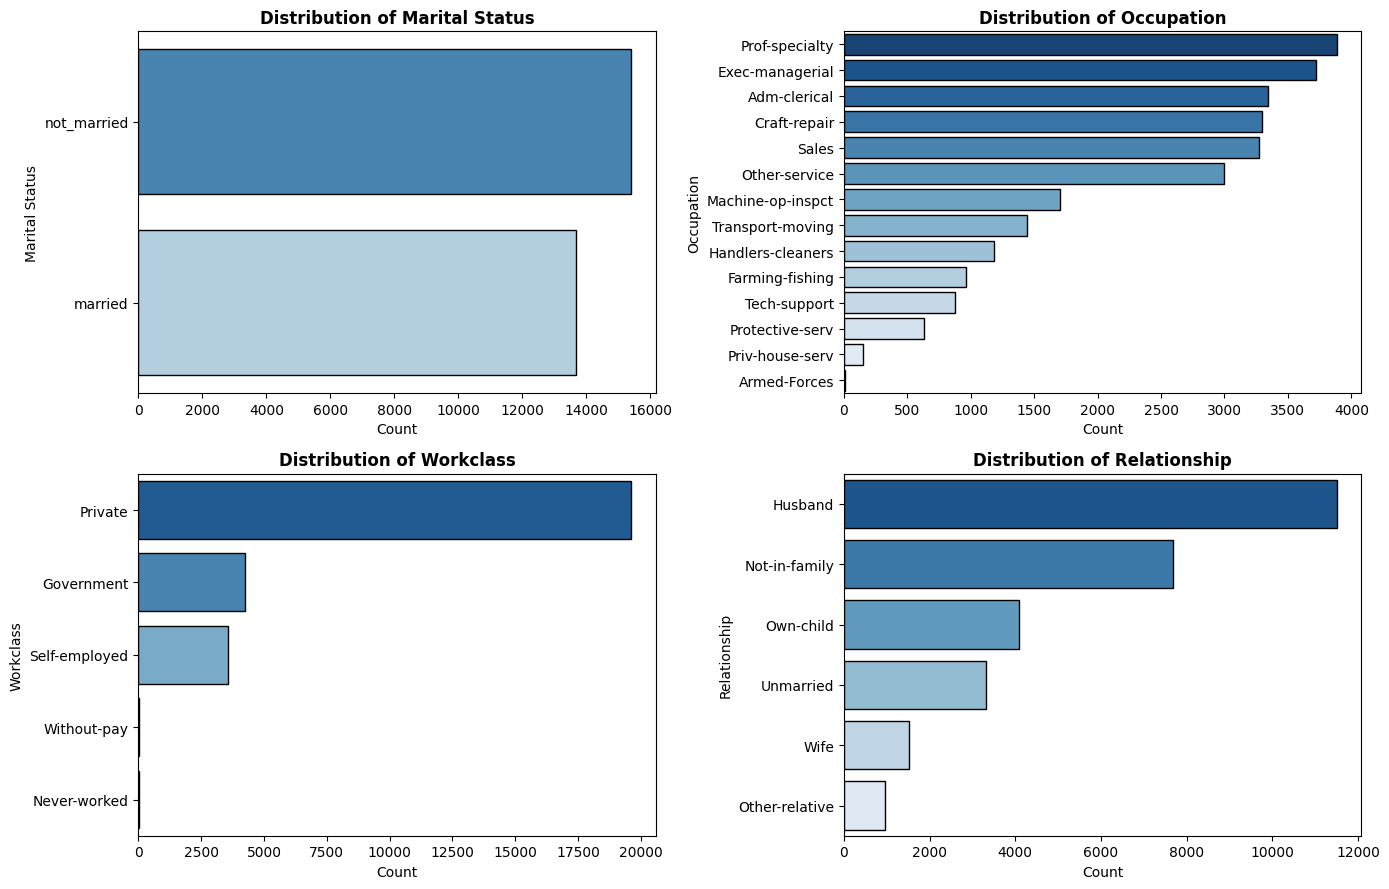

In [38]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

axes = axes.flatten()

cat_features = [
    'marital.status',
    'occupation',
    'workclass',
    'relationship'
]

for i, col in enumerate(cat_features):

    order = df[col].value_counts().index

    sns.countplot(
        data=df,
        y=col,
        order=order,
        ax=axes[i],
        palette='Blues_r',
        edgecolor='black'
    )

    axes[i].set_title(
        f'Distribution of {col.replace(".", " ").title()}',
        fontweight='bold'
    )

    axes[i].set_xlabel('Count')
    axes[i].set_ylabel(
        col.replace(".", " ").title()
    )

plt.tight_layout()
plt.show()

**Interpretation:** These subplots show how observations are distributed across the main categorical features. `occupation` and `workclass` in particular still have a long tail of smaller categories even after the Section 4 consolidation, which the encoding strategy in Section 9 (target encoding for `occupation`, one-hot for `workclass`) is chosen to handle.

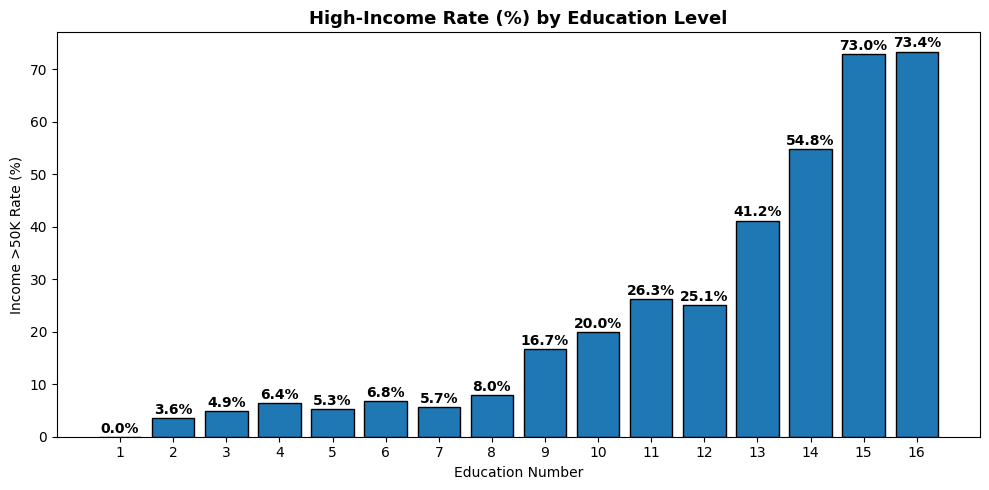

In [39]:
edu_target = (
    df.groupby('education.num')['income']
    .agg(
        count='count',
        high_income_rate=lambda x: (x == '>50K').mean()
    )
    .reset_index()
)

edu_target['high_income_rate'] = edu_target['high_income_rate'] * 100

edu_target = edu_target.sort_values(
    by='education.num'
)

plt.figure(figsize=(10, 5))

bars = plt.bar(
    edu_target['education.num'],
    edu_target['high_income_rate'],
    color='#1f77b4',
    edgecolor='black'
)

plt.title(
    'High-Income Rate (%) by Education Level',
    fontweight='bold',
    fontsize=13
)

plt.xlabel('Education Number')
plt.ylabel('Income >50K Rate (%)')

plt.xticks(edu_target['education.num'])

for bar in bars:
    yval = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        yval + 0.8,
        f"{yval:.1f}%",
        ha='center',
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

**Interpretation:** This groupby view makes the education–income relationship from earlier even clearer at the bar level: the high-income rate climbs from single digits at the lowest education levels to well over 50% at the highest, a near-monotonic trend.

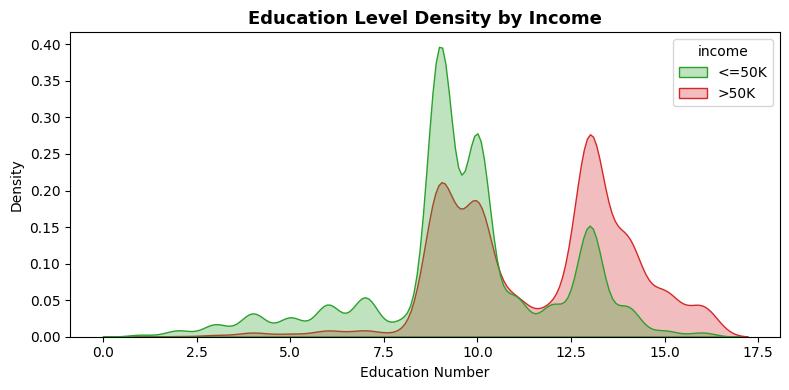

In [40]:
plt.figure(figsize=(8, 4))

sns.kdeplot(
    data=df,
    x='education.num',
    hue='income',
    common_norm=False,
    palette=['#2ca02c', '#d62728'],
    fill=True,
    alpha=0.3
)

plt.title(
    'Education Level Density by Income',
    fontweight='bold',
    fontsize=13
)

plt.xlabel('Education Number')
plt.ylabel('Density')

plt.tight_layout()
plt.show()

**Interpretation:** The density plot shows the `>50K` group's education distribution shifted noticeably to the right of the `<=50K` group's, with comparatively little overlap at the highest education levels — visual confirmation that `education.num` is one of the stronger individual predictors.

C:\Users\Saif_Alaswad\AppData\Local\Temp\ipykernel_9332\3517315560.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot(


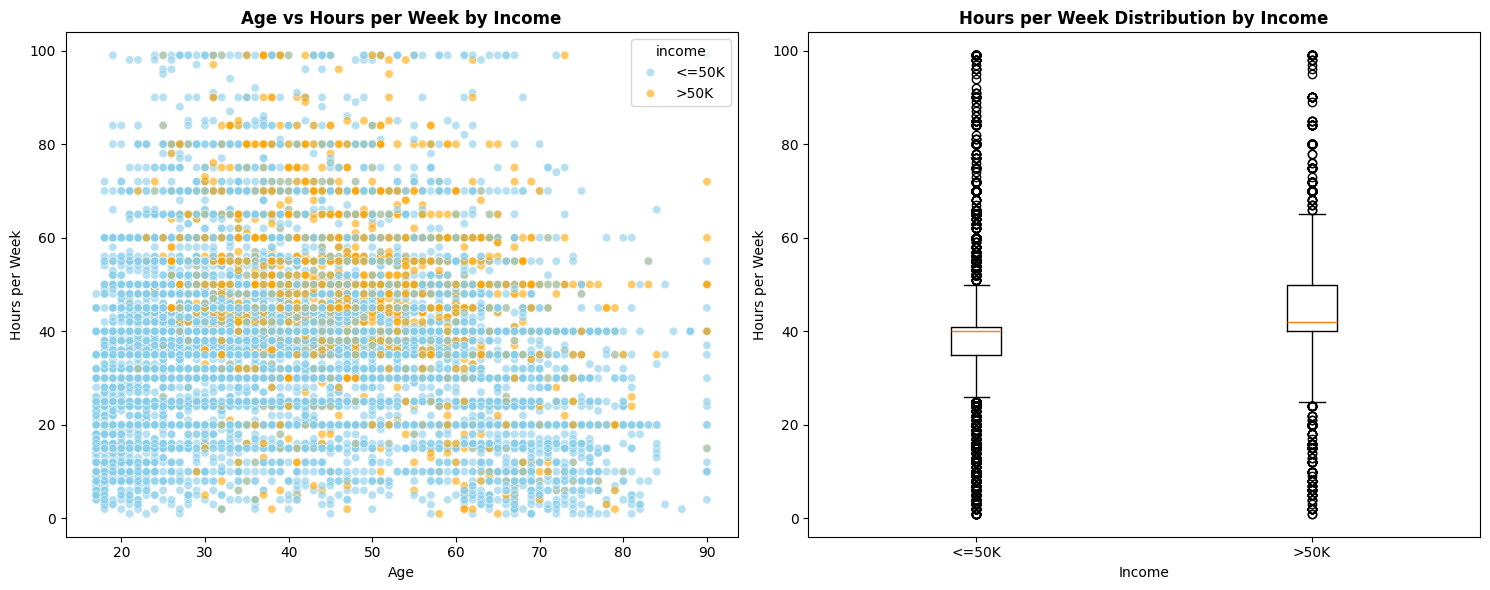

In [41]:
train_plot = df.copy()

fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(15, 6)
)
sns.scatterplot(
    data=train_plot,
    x='age',
    y='hours.per.week',
    hue='income',
    palette=['skyblue', 'orange'],
    alpha=0.6,
    ax=ax1
)

ax1.set_title(
    'Age vs Hours per Week by Income',
    fontweight='bold'
)

ax1.set_xlabel('Age')
ax1.set_ylabel('Hours per Week')
income_low = train_plot.loc[
    train_plot['income'] == '<=50K',
    'hours.per.week'
].dropna()

income_high = train_plot.loc[
    train_plot['income'] == '>50K',
    'hours.per.week'
].dropna()

ax2.boxplot(
    [income_low, income_high],
    labels=['<=50K', '>50K']
)

ax2.set_title(
    'Hours per Week Distribution by Income',
    fontweight='bold'
)

ax2.set_xlabel('Income')
ax2.set_ylabel('Hours per Week')

plt.tight_layout()
plt.show()

**Interpretation:** The boxplot on the right makes the earlier hours-vs-income trend concrete: the median weekly hours for `>50K` earners sit noticeably above 40, while `<=50K` earners cluster closer to (or below) the standard 40-hour week.

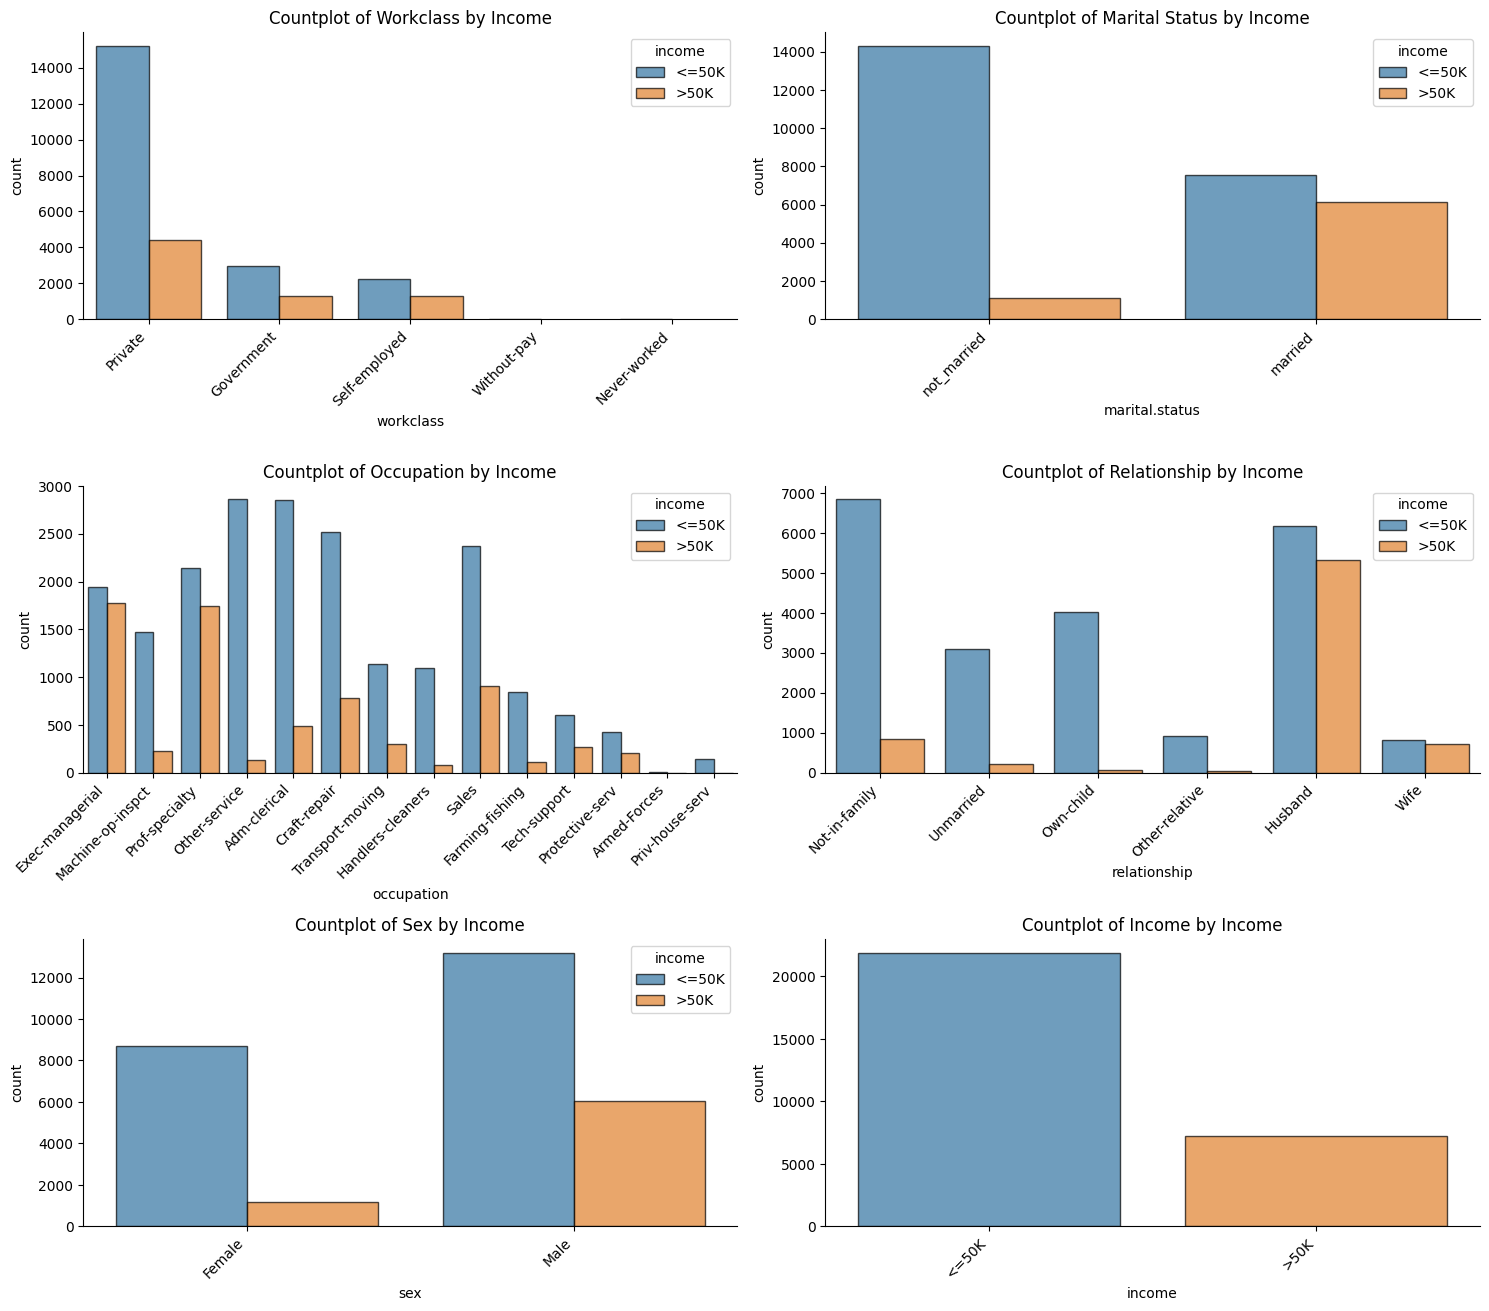

In [42]:
plt.figure(figsize=[15, 17])

plot = [
    "workclass",
    "marital.status",
    "occupation",
    "relationship",
    "sex",
    "income"
]

n = 1

for f in plot:

    plt.subplot(4, 2, n)

    sns.countplot(
        x=f,
        hue='income',
        edgecolor="black",
        alpha=0.7,
        data=df
    )

    sns.despine()

    plt.title(
        "Countplot of {} by Income".format(
            f.replace(".", " ").title()
        )
    )

    plt.xticks(rotation=45, ha='right')

    n += 1

plt.tight_layout()
plt.show()

**Interpretation:** Breaking each categorical feature down by `income` highlights which categories (which relationship roles, occupations, workclasses) are more associated with higher earners — e.g. `Husband`/`Wife` relationship roles and executive/managerial or professional-specialty occupations stand out with a higher `>50K` share than the rest.

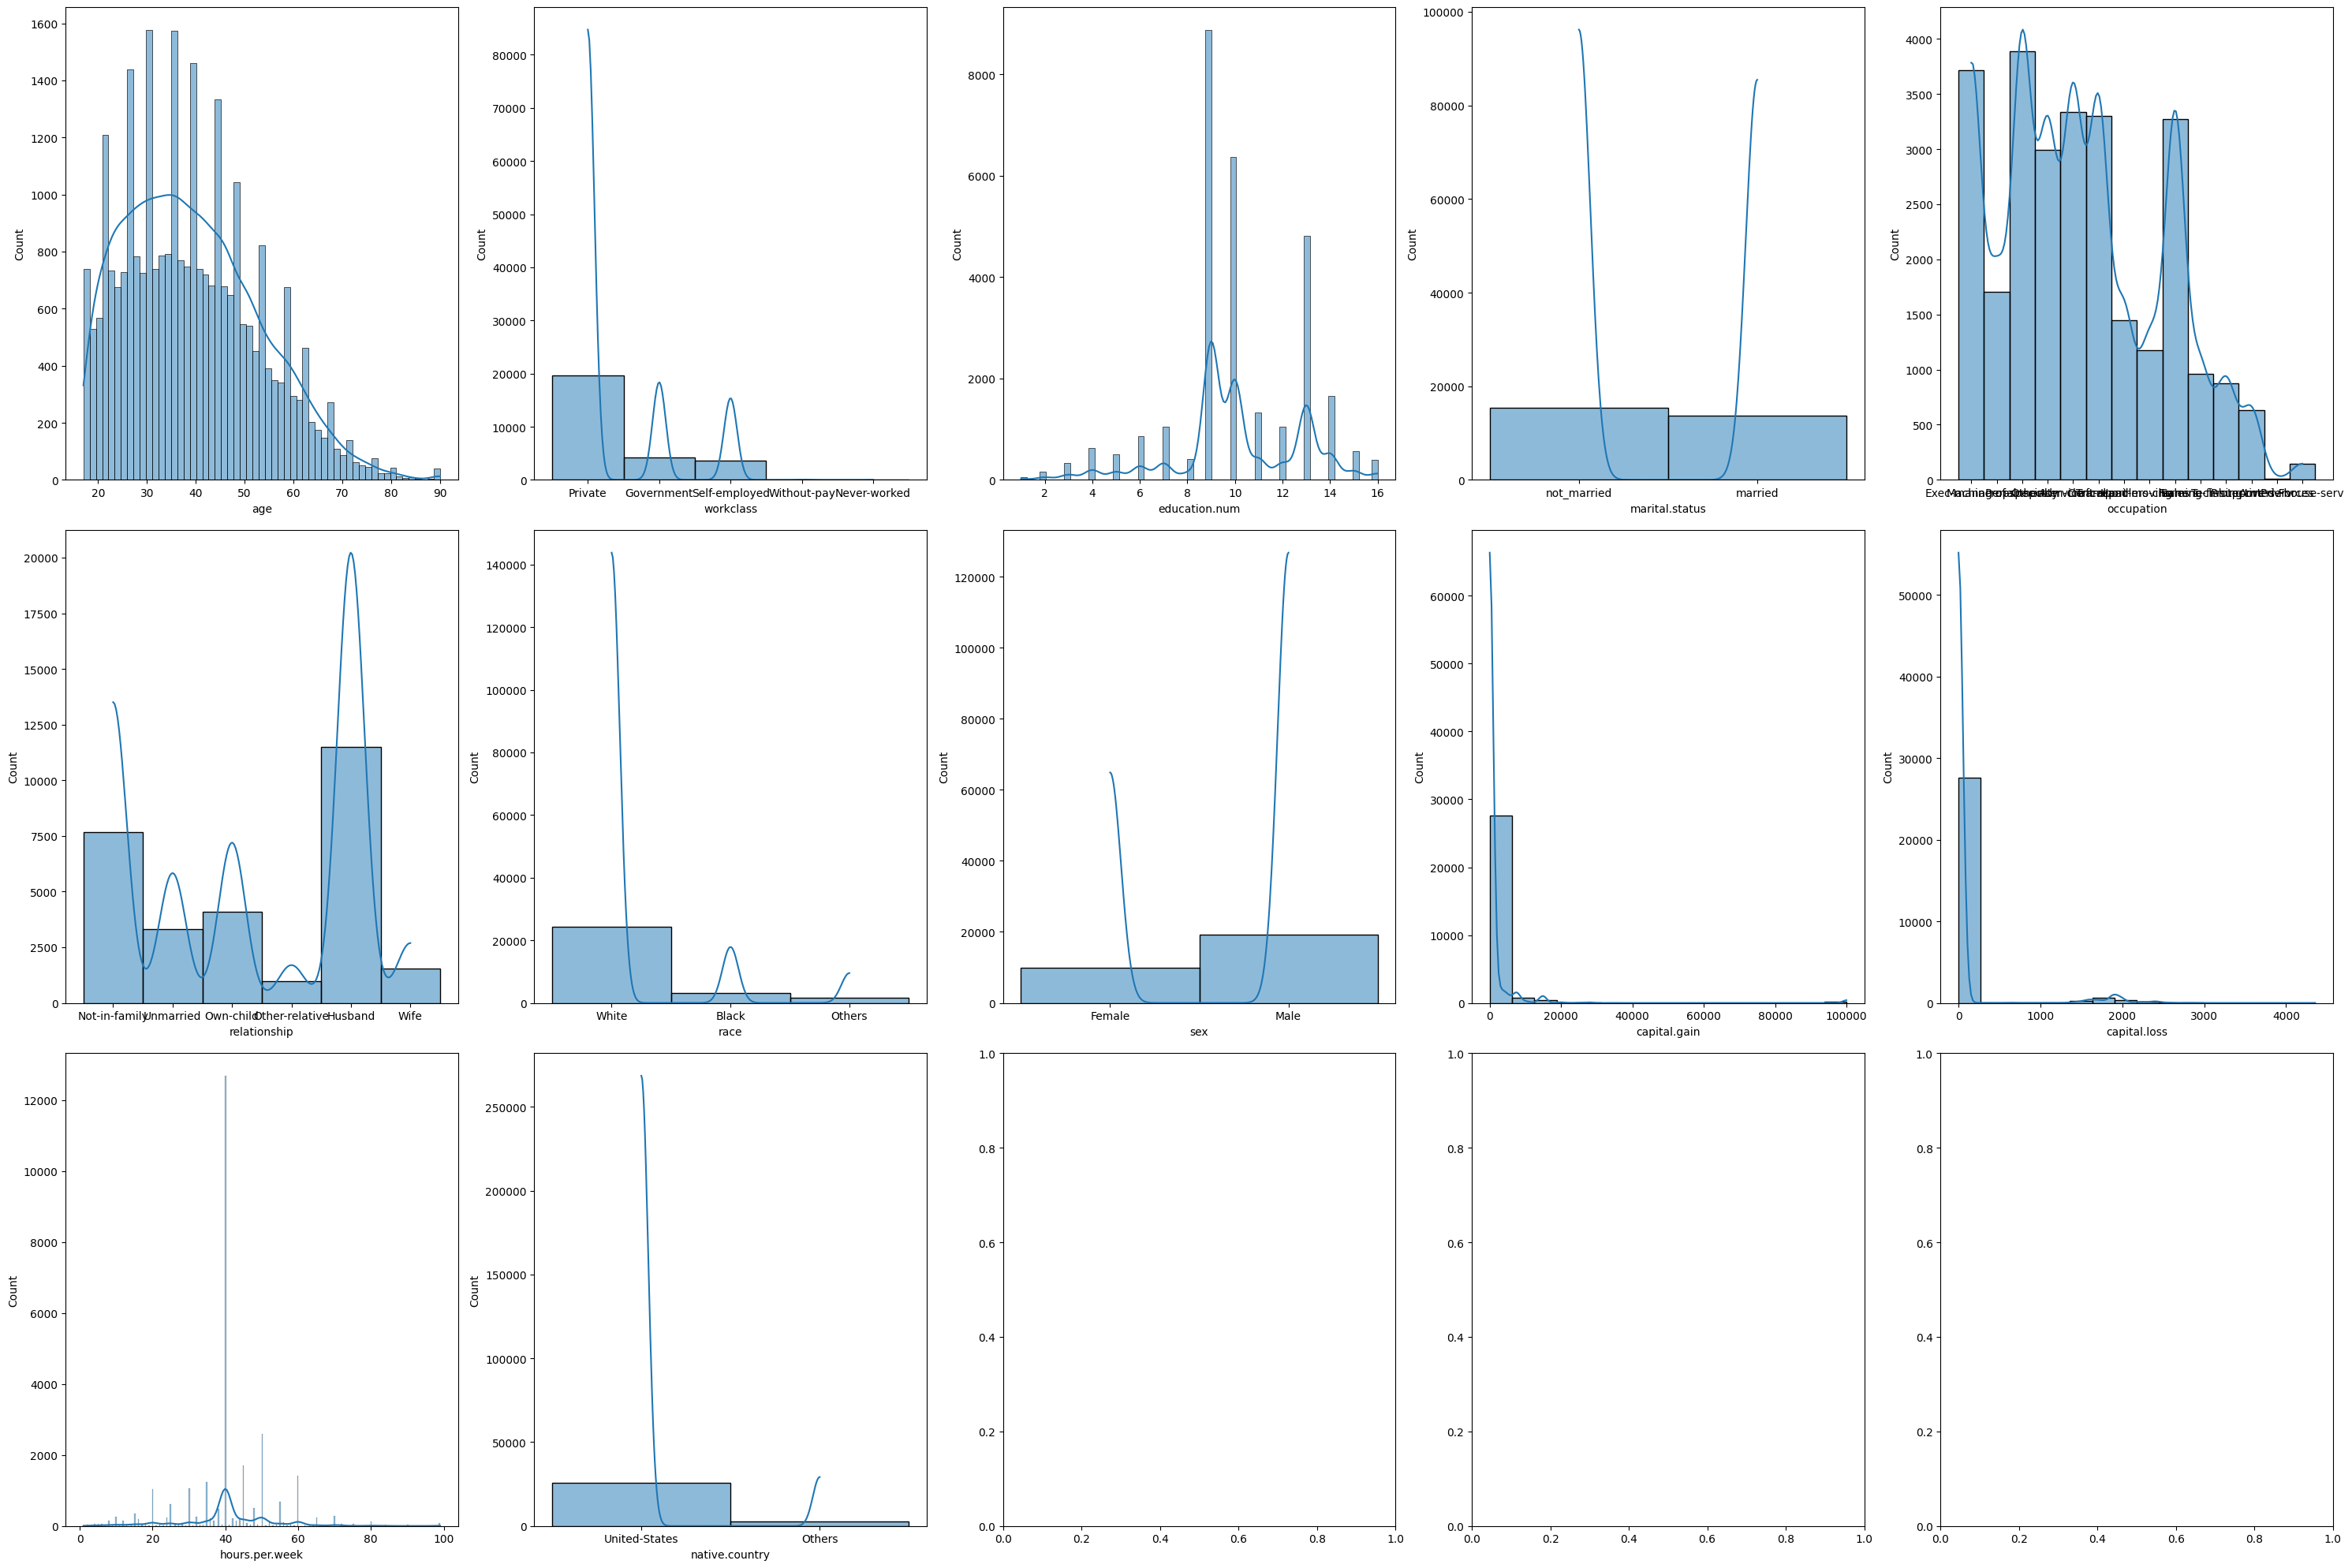

In [43]:
fig, ax = plt.subplots(3, 5, figsize=(30, 20))
ax = ax.flatten()
i = 0
for col in df.columns:
    if(col != 'income'):
        sns.histplot(data=df, x=col, kde=True, ax=ax[i])
        i += 1
plt.tight_layout()

**Interpretation:** This full grid gives a single at-a-glance view of every feature's marginal distribution, confirming the same skew patterns (`capital.gain`, `capital.loss`) and category imbalances (`native.country`, `race`) already surfaced individually above.

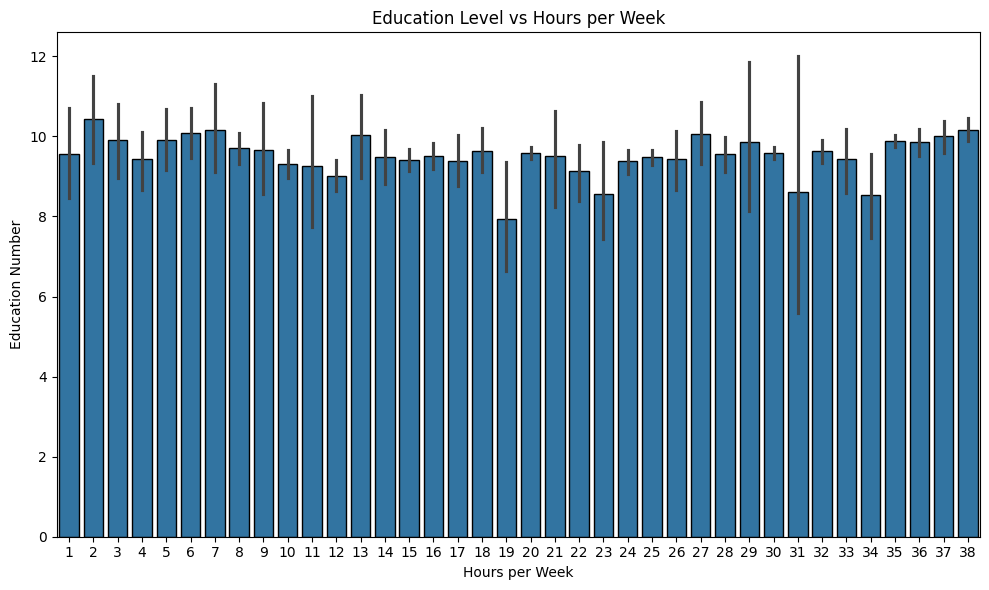

In [44]:
et = df.sort_values(
    by='hours.per.week',
    ascending=True
).head(7000)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=et,
    y='education.num',
    x='hours.per.week',
    edgecolor='black'
)

plt.xlabel('Hours per Week')
plt.ylabel('Education Number')

plt.title('Education Level vs Hours per Week')

plt.tight_layout()
plt.show()

**Interpretation:** Restricted to the lowest-hours records, education level doesn't show a strong systematic relationship with hours worked, suggesting `education.num` and `hours.per.week` largely act as separate, complementary signals rather than a redundant pair.

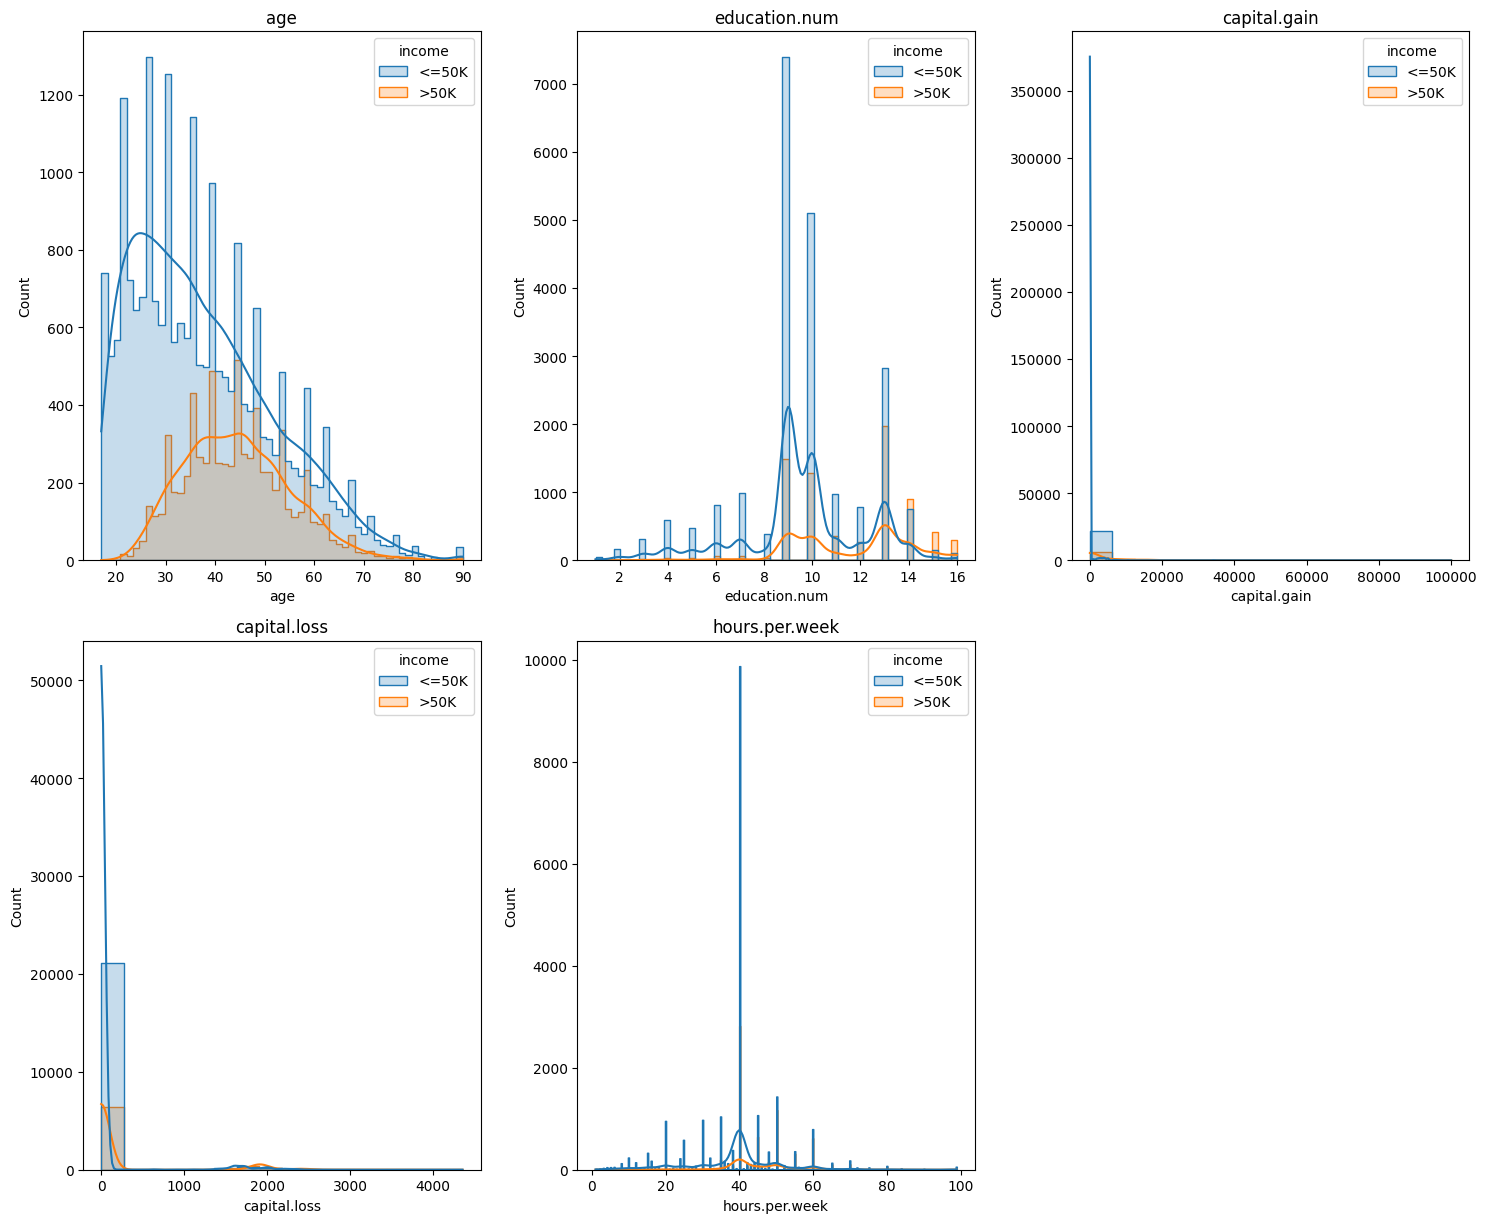

In [45]:
numerical_features = df.select_dtypes(include='number').columns

plt.figure(figsize=(15, 18))

for i, col in enumerate(numerical_features):

    plt.subplot(3, 3, i + 1)

    sns.histplot(
        data=df,
        x=col,
        hue='income',
        kde=True,
        element='step'
    )

    plt.title(col)

plt.tight_layout()
plt.show()

**Interpretation:** Overlaying the `income` classes on each numeric feature's histogram shows `age`, `education.num`, and `hours.per.week` all separate the two classes to some degree, while `capital.gain`/`capital.loss` mostly separate on whether the value is zero or non-zero rather than on magnitude.

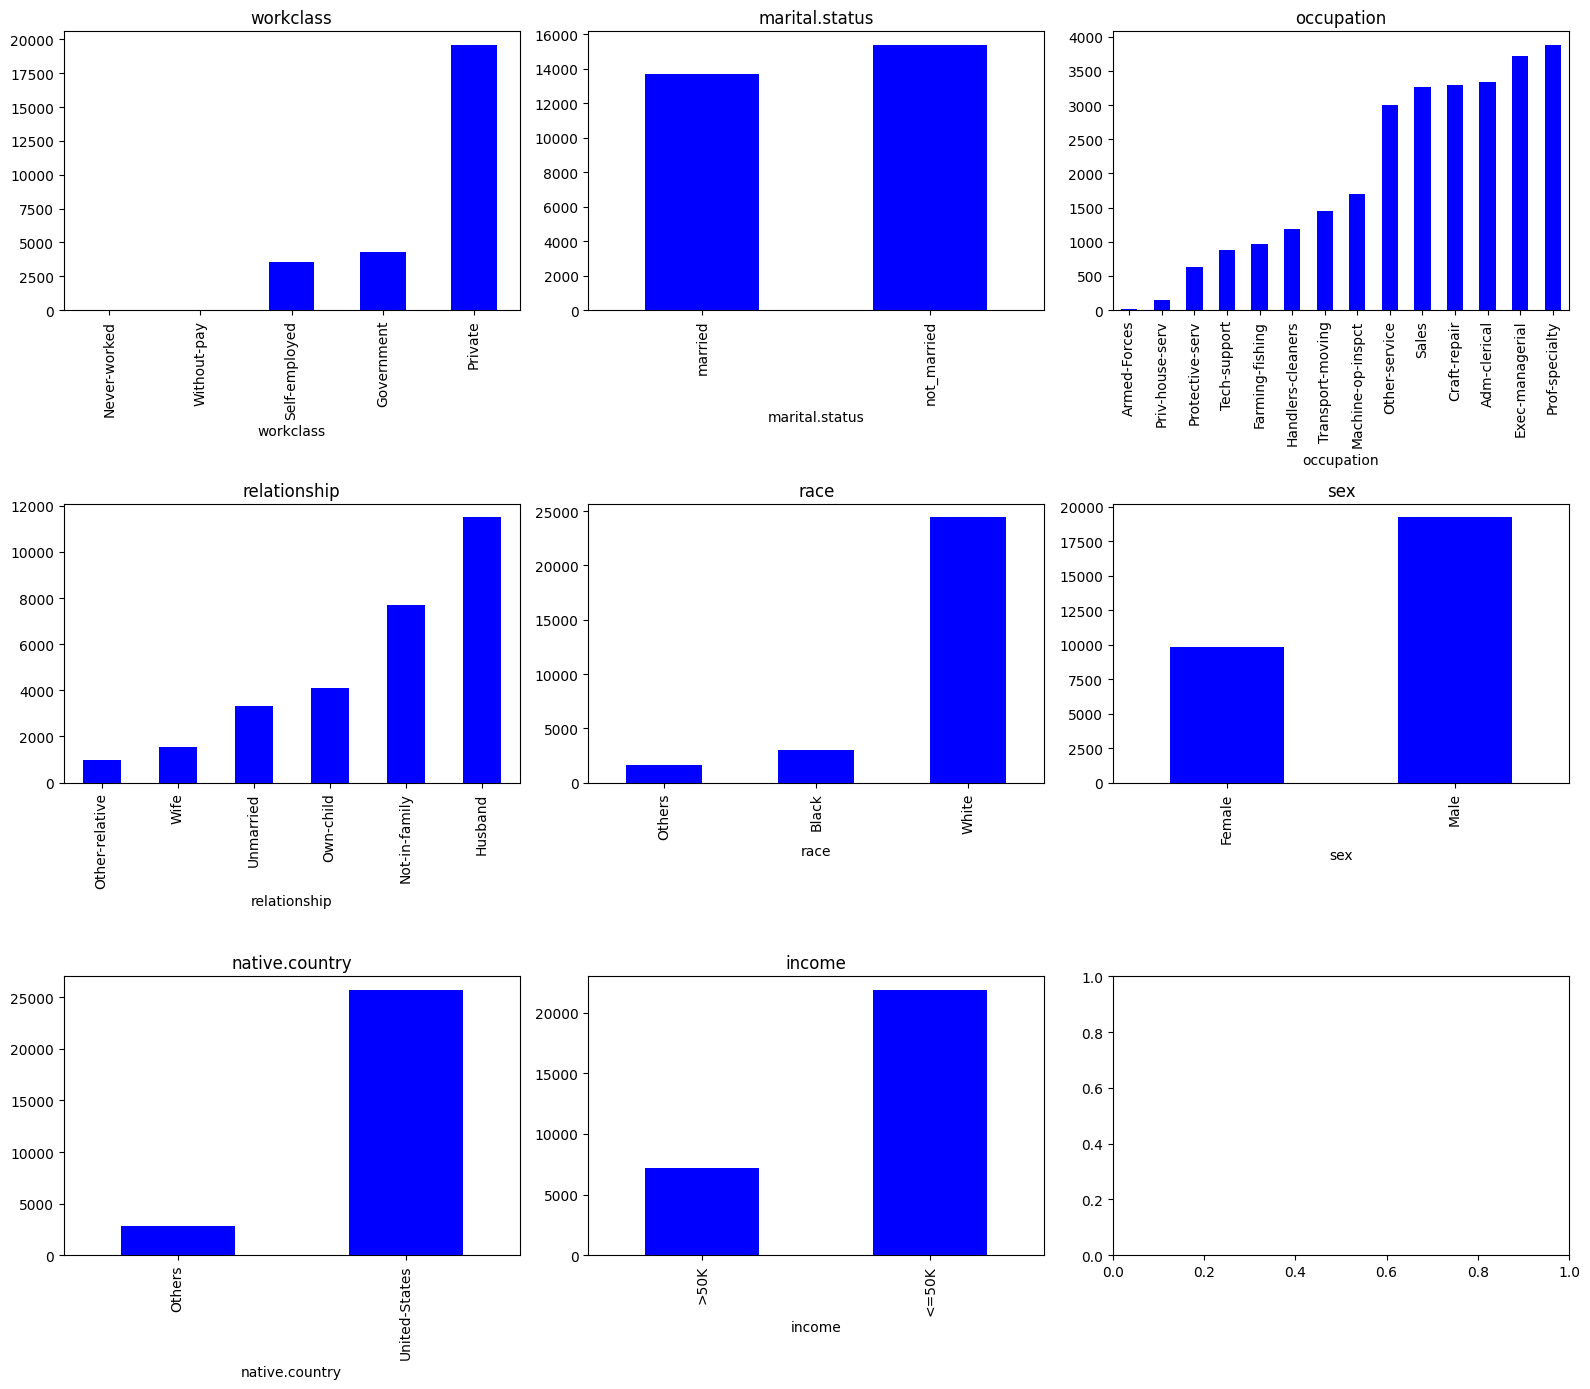

In [46]:
fields = df.select_dtypes(exclude="number").columns
figuresize = (16, 14)
cols = 3
rows = math.ceil(len(fields)/cols)
plt.subplots(rows, cols, figsize=figuresize)
for i in range(1, len(fields)+1):
    plt.subplot(rows, cols, i)
    df[fields[i-1]].value_counts().sort_values().plot.bar(color='blue')
    plt.xticks(rotation=90)
    plt.title(fields[i-1])
plt.tight_layout()
plt.show()

**Interpretation:** This grid of bar charts across every categorical column gives one final, compact confirmation of each feature's category counts after the Section 4 consolidation — no column shows an unexpected new category or leftover placeholder text.


(workclass)
workclass
Private          67.435386
Government       14.634314
Self-employed    12.249106
NaN               5.609018
Without-pay       0.048117
Never-worked      0.024058
Name: proportion, dtype: float64
Most Frequent: Private
Missing: 1632

(marital.status)
marital.status
not_married    52.948859
married        47.051141
Name: proportion, dtype: float64
Most Frequent: not_married
Missing: 0

(occupation)
occupation
Prof-specialty       13.352351
Exec-managerial      12.781826
Adm-clerical         11.479241
Craft-repair         11.334891
Sales                11.238658
Other-service        10.296948
Machine-op-inspct     5.849601
NaN                   5.633077
Transport-moving      4.966318
Handlers-cleaners     4.052103
Farming-fishing       3.306296
Tech-support          3.003849
Protective-serv       2.168683
Priv-house-serv       0.505224
Armed-Forces          0.030932
Name: proportion, dtype: float64
Most Frequent: Prof-specialty
Missing: 1639

(relationship)
relation

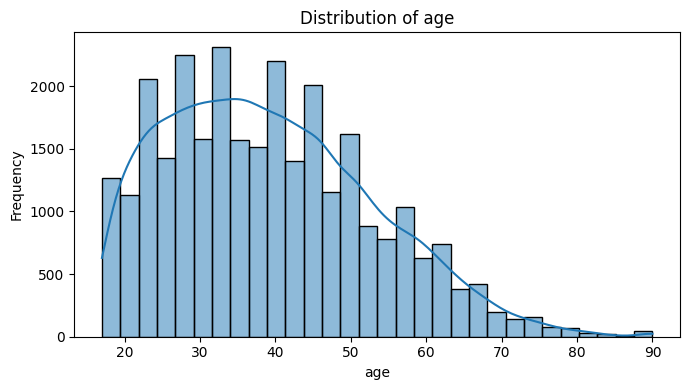

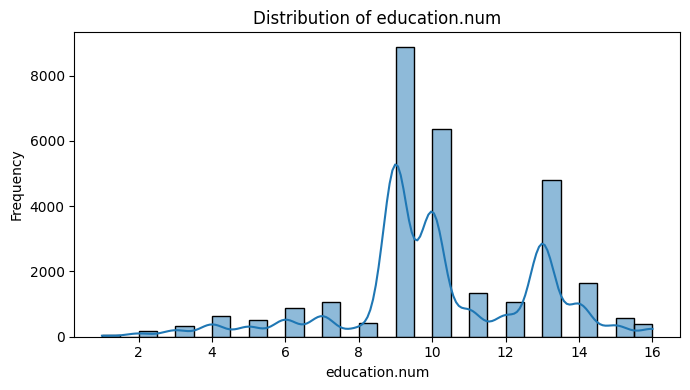

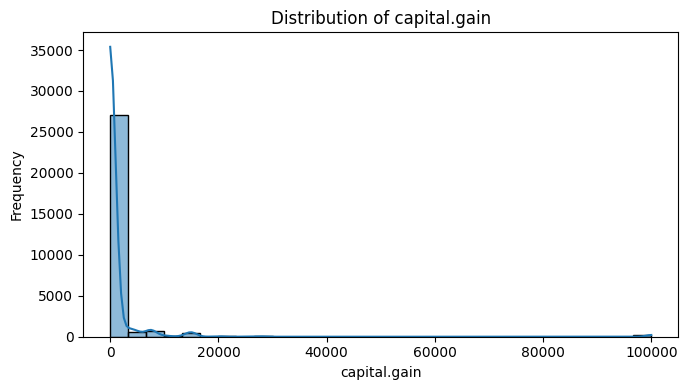

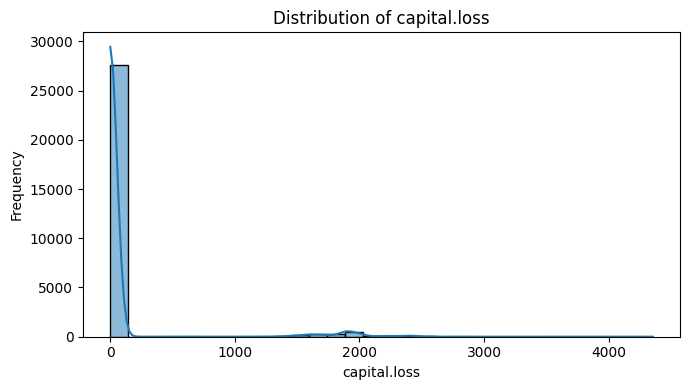

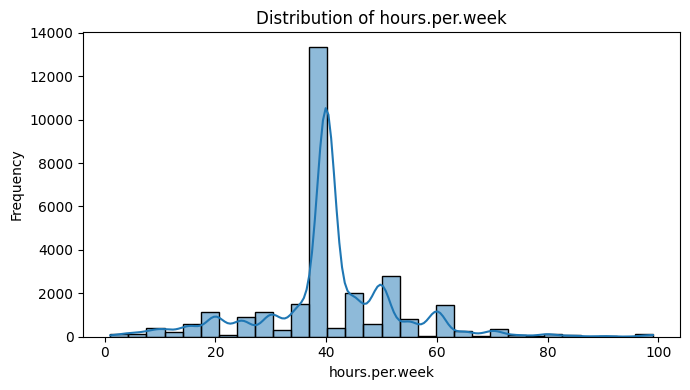

In [47]:
categorical_cols = [
    'workclass',
    'marital.status',
    'occupation',
    'relationship',
    'race',
    'sex',
    'native.country'
]

for col in categorical_cols:

    print(f"\n({col})")

    print(df[col].value_counts(normalize=True, dropna=False) * 100)

    print(f"Most Frequent: {df[col].mode()[0]}")

    print(f"Missing: {df[col].isnull().sum()}")


numeric_cols = [
    'age',
    'education.num',
    'capital.gain',
    'capital.loss',
    'hours.per.week'
]

for col in numeric_cols:

    print(f"\n({col})")

    print(f"Mean: {df[col].mean():.2f}")

    print(f"Median: {df[col].median():.2f}")

    print(f"Std: {df[col].std():.2f}")

    print(f"Skewness: {df[col].skew():.2f}")

    print(f"Min: {df[col].min()}, Max: {df[col].max()}")


for col in numeric_cols:

    plt.figure(figsize=(7, 4))

    sns.histplot(
        df[col].dropna(),
        bins=30,
        kde=True
    )

    plt.title(f'Distribution of {col}')

    plt.xlabel(col)

    plt.ylabel('Frequency')

    plt.tight_layout()

    plt.show()

**Interpretation:** This consolidated numeric/categorical summary confirms, in one place, the mode/most-frequent category for each categorical column (useful context for the most-frequent imputation strategy used later) and the skewness of each numeric column (`capital.gain` and `capital.loss` show by far the highest skew, consistent with the boxplots earlier).

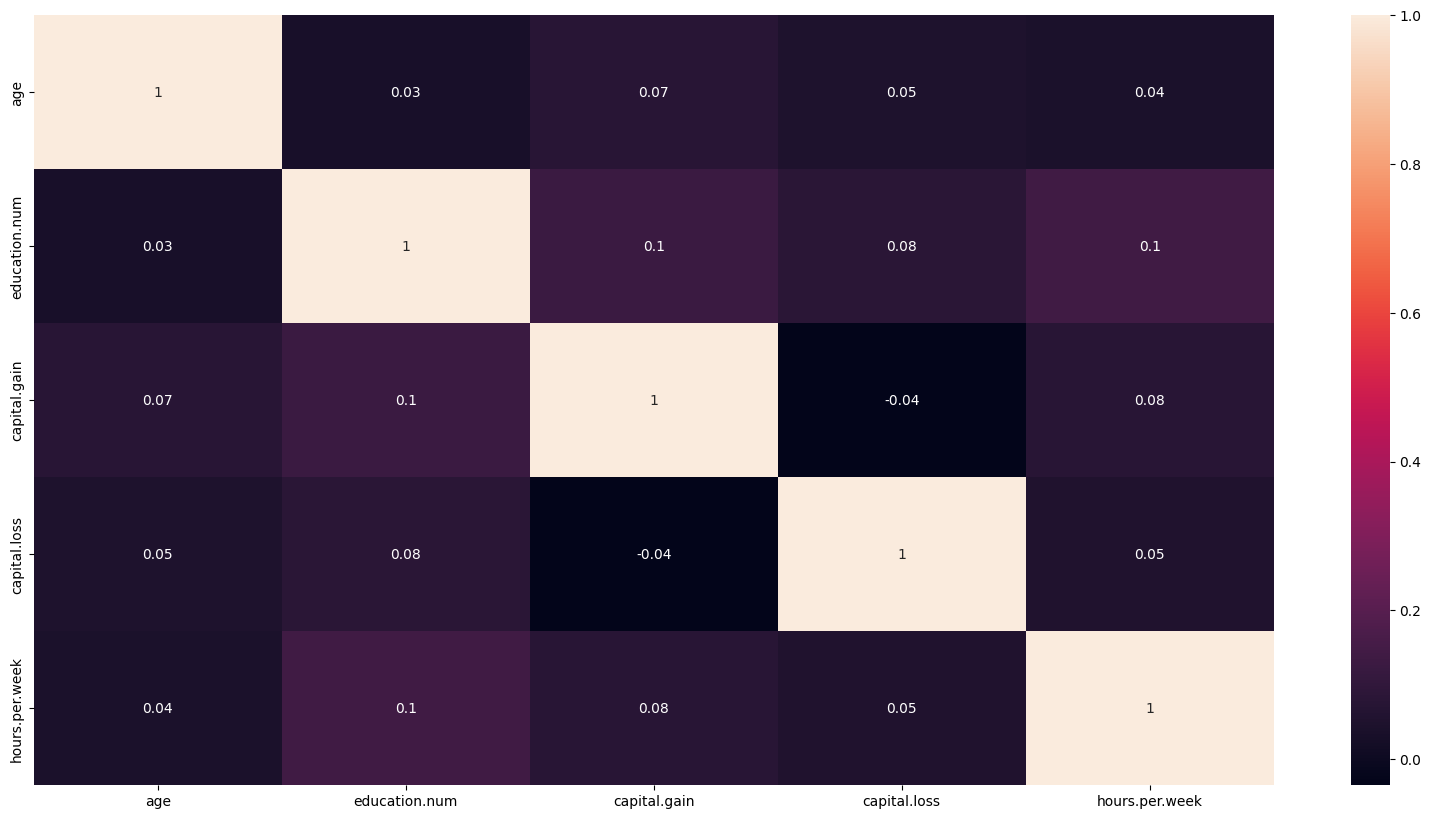

In [48]:
plt.figure(figsize=(20, 10))
numeric_df = df.select_dtypes(include=['int64', 'float64'])
sns.heatmap(numeric_df.corr(), annot=True, fmt='.1g')
plt.show()

**Interpretation:** The correlation heatmap over the raw numeric features shows no strong linear redundancy between them (all off-diagonal values are fairly small), meaning multicollinearity between `age`, `education.num`, `capital.gain`, `capital.loss`, and `hours.per.week` is not a major concern going into modeling.

In [49]:
df.duplicated().sum()

np.int64(557)

In [50]:
df.drop_duplicates(keep='first', inplace=True)
df.reset_index(drop=True, inplace=True)

**Interpretation:** A final duplicate check/removal closes out the EDA stage — no further duplicates are found beyond what was already handled in Section 4, confirming the cleaned `df` used for feature engineering and modeling below is fully deduplicated.

## 6. Feature Engineering

One engineered feature is added on top of the cleaned raw signals: `capital_diff`, the net of `capital.gain` minus `capital.loss`. This combines two heavily-skewed, mostly-zero columns into a single net figure, which is often more directly informative for income than the two components separately.

In [51]:
def apply_feature_engineering(df_clean):
    d = df_clean.copy()
    d['capital_diff'] = d['capital.gain'] - d['capital.loss']
    return d

In [52]:
df = apply_feature_engineering(df)
df[['capital.gain', 'capital.loss', 'capital_diff']].describe()

,capital.gain,capital.loss,capital_diff
count,28539.000000,28539.000000,28539.000000
mean,1220.487438,99.071761,1121.415677
std,7851.748669,427.906592,7878.762680
min,0.000000,0.000000,-4356.000000
25%,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000
max,99999.000000,4356.000000,99999.000000


**Interpretation:** `capital_diff` is net capital gains, so it's positive for individuals with large capital gains, negative for those with large capital losses, and zero for the majority who report neither — providing a single combined signal instead of two separately-skewed columns. Wrapping this in `apply_feature_engineering()` (rather than a one-off script cell) means it can be replayed identically on a single new row at inference time.

## 7. Define Features and Target

In [53]:
df['income'] = df['income'].map({
    '<=50K': 0,
    '>50K': 1
})

X = df.drop('income', axis=1)
y = df['income']

**Data separation — Features (X) vs. Target (y):** The target `income` is mapped to `0`/`1` (`<=50K` / `>50K`) so it can be used directly with classification metrics and models. `X` contains every remaining column; nothing is dropped here as a leakage concern (unlike a regression target's direct derivatives), since all remaining columns are independent demographic/employment attributes.

In [54]:
raw_input_columns = X.columns.tolist()
print('Raw input columns a Streamlit form must collect:', raw_input_columns)

Raw input columns a Streamlit form must collect: ['age', 'workclass', 'education.num', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'capital.gain', 'capital.loss', 'hours.per.week', 'native.country', 'capital_diff']


**Deployment note:** `raw_input_columns` is exactly the set of fields a Streamlit form needs to collect from the user to build a valid one-row input DataFrame (before feature engineering adds `capital_diff`). It is saved as part of `feature_columns_config.pkl` in Section 13.

## 8. Train/Test Split

In [55]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train.reset_index(drop=True, inplace=True)
X_test.reset_index(drop=True, inplace=True)
y_train.reset_index(drop=True, inplace=True)
y_test.reset_index(drop=True, inplace=True)

**Data separation — Train vs. Test split:** The data is split 80% train / 20% test with a fixed `random_state` for reproducibility, and `stratify=y` preserves the ~76/24 class imbalance noted in Section 5 in both splits. The training set is used to fit every preprocessing step and every model; the test set is held out purely for unbiased evaluation and is never used to fit anything.

## 9. Preprocessing

Every transformer below follows the same pattern: **fit on `X_train` only, transform `X_train`, then transform `X_test` using the already-fitted transformer.** Nothing here is fit on the full dataset or on `X_test`, which prevents data leakage. Each fitted object is saved immediately with `joblib` so the exact same transformation can be replayed on a single new row at inference time.

In [56]:
missing = ['occupation', 'workclass', 'native.country']
imputer = SimpleImputer(missing_values=np.nan, strategy='most_frequent')
X_train[missing] = imputer.fit_transform(X_train[missing])
X_test[missing] = imputer.transform(X_test[missing])

### Imputation — Categorical Features

The three columns with missing values (`occupation`, `workclass`, `native.country`) are filled using the **most frequent category** of each column, fit on `X_train` only and then applied to `X_test`. The fitted imputer is saved to disk immediately below.

In [57]:
joblib.dump(imputer, "categorical_imputer.pkl")

['categorical_imputer.pkl']

In [58]:
X_train.isnull().sum().sum(), X_test.isnull().sum().sum()

(np.int64(0), np.int64(0))

**Interpretation:** Both splits now show zero missing values — imputation is complete.

### 9.1 Encoding categorical features

Machine-learning models need numeric input, so every remaining categorical/text column is converted to a numeric representation. The encoding strategy is chosen per column based on its cardinality and whether it has a natural order.

In [59]:
sex_map = {'Female': 0, 'Male': 1}
X_train['sex'] = X_train['sex'].map(sex_map)
X_test['sex'] = X_test['sex'].map(sex_map)
joblib.dump(sex_map, "sex_encoder.pkl")

['sex_encoder.pkl']

**Encoding `sex` (binary mapping):** A simple 0/1 mapping, since `sex` only has two categories.

In [60]:
country_map = {'United-States': 0, 'Others': 1}
X_train['native.country'] = X_train['native.country'].map(country_map)
X_test['native.country'] = X_test['native.country'].map(country_map)
joblib.dump(country_map, "native_country_encoder.pkl")

['native_country_encoder.pkl']

**Encoding `native.country` (binary mapping):** After the Section 4 consolidation this column already only has two values (`United-States` / `Others`), so it is mapped directly to 0/1 rather than one-hot encoded.

In [61]:
marital_map = {'not_married': 0, 'married': 1}
X_train['marital.status'] = X_train['marital.status'].map(marital_map)
X_test['marital.status'] = X_test['marital.status'].map(marital_map)
joblib.dump(marital_map, "marital_status_encoder.pkl")

['marital_status_encoder.pkl']

**Encoding `marital.status` (binary mapping):** Likewise reduced to two categories in Section 4, so it is mapped directly to 0/1.

In [62]:
ohe_cols = ['workclass', 'relationship', 'race']
ohe = OneHotEncoder(
    sparse_output=False,
    handle_unknown='ignore',
)
train_encoded = ohe.fit_transform(X_train[ohe_cols])
test_encoded = ohe.transform(X_test[ohe_cols])

encoded_cols = ohe.get_feature_names_out(ohe_cols)
train_encoded = pd.DataFrame(
    train_encoded,
    columns=encoded_cols,
    index=X_train.index
)
test_encoded = pd.DataFrame(
    test_encoded,
    columns=encoded_cols,
    index=X_test.index
)
X_train = pd.concat(
    [X_train.drop(columns=ohe_cols), train_encoded],
    axis=1
)
X_test = pd.concat(
    [X_test.drop(columns=ohe_cols), test_encoded],
    axis=1
)

joblib.dump(ohe, "onehot_encoder.pkl")

['onehot_encoder.pkl']

**Encoding `workclass`, `relationship`, `race` (One-Hot Encoding):** These columns have no natural order and a manageable number of categories after Section 4's consolidation, so `OneHotEncoder` creates one binary column per category. `handle_unknown='ignore'` makes the encoder safe to reuse on new data that might contain an unseen category. The fitted encoder is saved immediately above.

In [63]:
target_enc = TargetEncoder(cols=['occupation'])
X_train['occupation'] = target_enc.fit_transform(X_train['occupation'], y_train)
X_test['occupation'] = target_enc.transform(X_test['occupation'])

joblib.dump(target_enc, "occupation_target_encoder.pkl")

['occupation_target_encoder.pkl']

**Encoding `occupation` (Target Encoding):** `occupation` still has the highest cardinality among the remaining categorical columns (Section 5), so rather than exploding it into many sparse one-hot columns, each category is replaced with the mean target rate learned **from `X_train`/`y_train` only**, then applied to `X_test` with the already-fitted encoder — avoiding leakage from the test set's own target values.

In [64]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22831 entries, 0 to 22830
Data columns (total 24 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   age                          22831 non-null  int64  
 1   education.num                22831 non-null  int64  
 2   marital.status               22831 non-null  int64  
 3   occupation                   22831 non-null  float64
 4   sex                          22831 non-null  int64  
 5   capital.gain                 22831 non-null  int64  
 6   capital.loss                 22831 non-null  int64  
 7   hours.per.week               22831 non-null  int64  
 8   native.country               22831 non-null  int64  
 9   capital_diff                 22831 non-null  int64  
 10  workclass_Government         22831 non-null  float64
 11  workclass_Never-worked       22831 non-null  float64
 12  workclass_Private            22831 non-null  float64
 13  workclass_Self-e

In [65]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5708 entries, 0 to 5707
Data columns (total 24 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   age                          5708 non-null   int64  
 1   education.num                5708 non-null   int64  
 2   marital.status               5708 non-null   int64  
 3   occupation                   5708 non-null   float64
 4   sex                          5708 non-null   int64  
 5   capital.gain                 5708 non-null   int64  
 6   capital.loss                 5708 non-null   int64  
 7   hours.per.week               5708 non-null   int64  
 8   native.country               5708 non-null   int64  
 9   capital_diff                 5708 non-null   int64  
 10  workclass_Government         5708 non-null   float64
 11  workclass_Never-worked       5708 non-null   float64
 12  workclass_Private            5708 non-null   float64
 13  workclass_Self-emp

**Interpretation:** All features in `X_train` / `X_test` are now fully numeric — encoding is complete. Before scaling, a quick consistency check confirms both splits ended up with identical columns in identical order (a mismatch here would silently corrupt scaling/model input).

In [66]:
assert list(X_train.columns) == list(X_test.columns), "X_train/X_test columns diverged after encoding!"
print('OK: X_train and X_test have identical, aligned columns after encoding:', X_train.shape[1], 'columns')

OK: X_train and X_test have identical, aligned columns after encoding: 24 columns


In [67]:
X_train.duplicated().sum()

np.int64(559)

**Interpretation:** A final duplicate check on the fully-encoded training features finds no new duplicates introduced by encoding.

### 9.2 Scaling numeric features

In [68]:
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

joblib.dump(scaler, "standard_scaler.pkl")

['standard_scaler.pkl']

**Interpretation:** `StandardScaler` is applied to the numeric columns, fit on `X_train` only and then applied to `X_test`. This puts every numeric feature on a comparable scale, which matters most for the linear and instance-based models (Logistic Regression, KNN) compared in Section 11; the tree-based/boosting models are scale-invariant but are unaffected by the transformation either way. The fitted scaler is saved immediately above.

## 10. Feature Selection

Mutual Information is used to rank features by how much information they provide about `income` (capturing non-linear relationships, unlike a Pearson correlation), and the top features by `SelectKBest` are kept for model training below.

                  Feature  Mutual Information
0            capital_diff            0.135742
1            capital.gain            0.098882
2          marital.status            0.098263
3    relationship_Husband            0.076644
4           education.num            0.068984
5                     age            0.060063
6              occupation            0.055207
7          hours.per.week            0.042159
8            capital.loss            0.037476
9  relationship_Own-child            0.034618


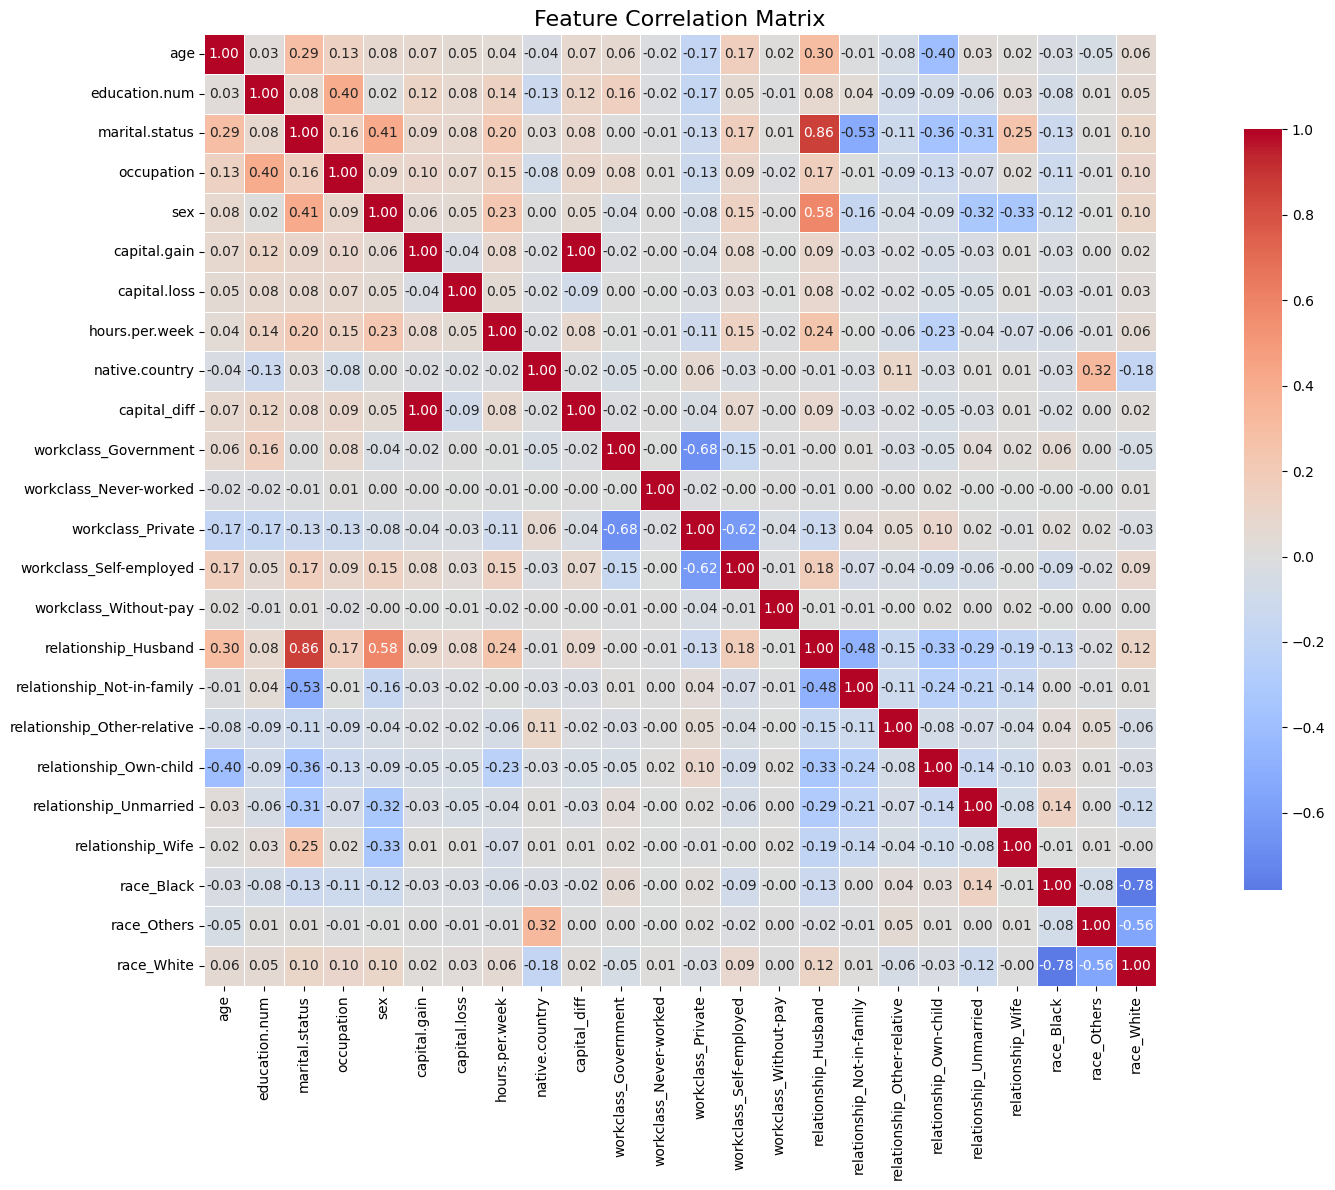

C:\Users\Saif_Alaswad\AppData\Local\Temp\ipykernel_9332\1711357802.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


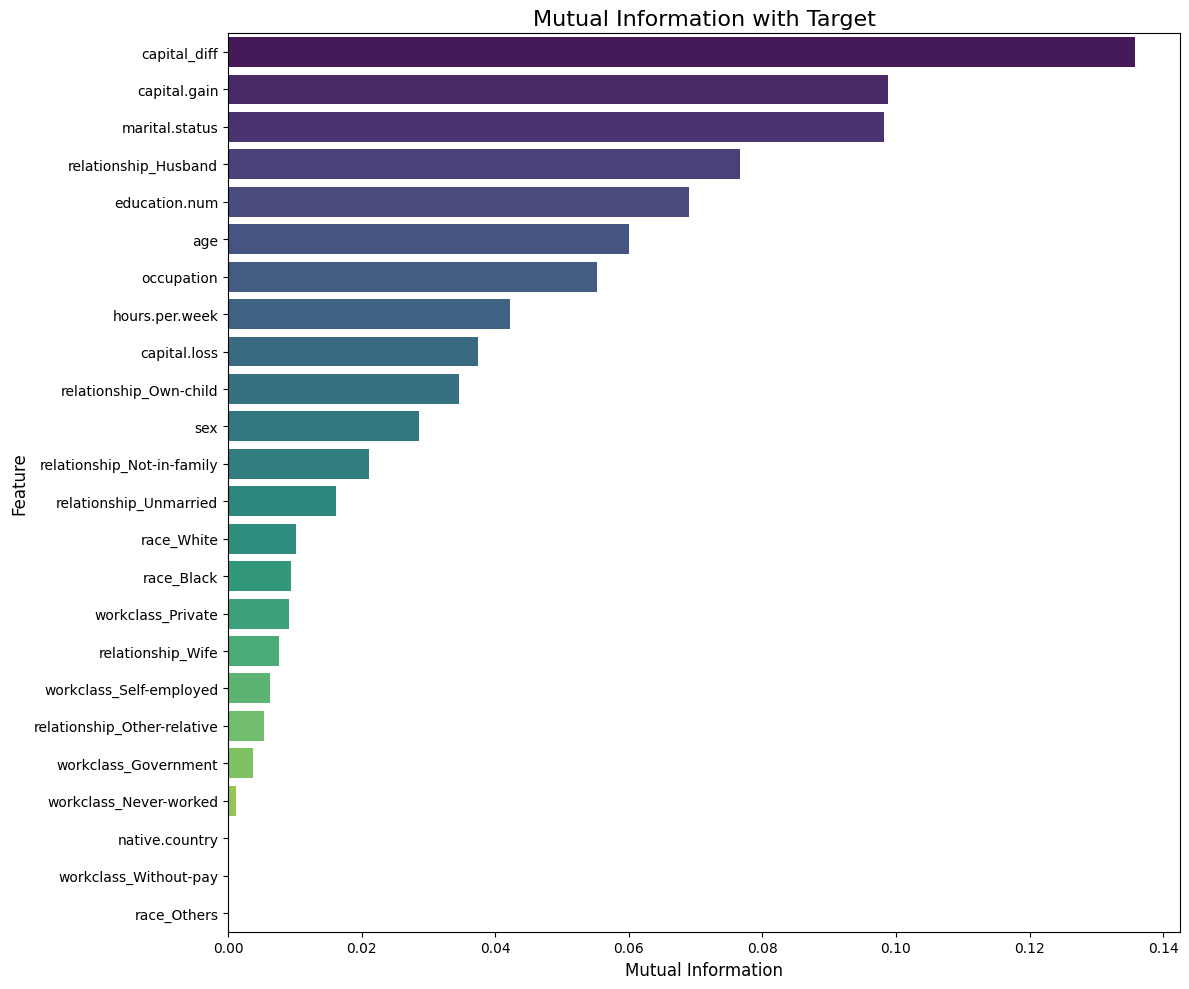

capital_diff - capital.gain: 0.998
relationship_Husband - marital.status: 0.857
['race_Black', 'workclass_Private', 'relationship_Wife', 'workclass_Self-employed', 'relationship_Other-relative', 'workclass_Government', 'workclass_Never-worked', 'native.country', 'workclass_Without-pay', 'race_Others']


In [69]:
X = X_train.copy()
y = y_train.copy()

mi = mutual_info_classif(
    X,
    y,
    random_state=1
)

mi_df = pd.DataFrame({
    'Feature': X.columns,
    'Mutual Information': mi
}).sort_values(
    by='Mutual Information',
    ascending=False
).reset_index(drop=True)

print(mi_df.head(10))

plt.figure(figsize=(18, 12))

corr_matrix = X.corr()
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title('Feature Correlation Matrix', fontsize=16)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 10))
sns.barplot(
    data=mi_df,
    x='Mutual Information',
    y='Feature',
    palette='viridis'
)
plt.title('Mutual Information with Target', fontsize=16)
plt.xlabel('Mutual Information', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()

threshold = 0.8
high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > threshold:
            high_corr_pairs.append((
                corr_matrix.columns[i],
                corr_matrix.columns[j],
                corr_matrix.iloc[i, j]
            ))

for pair in high_corr_pairs:
    print(f"{pair[0]} - {pair[1]}: {pair[2]:.3f}")

low_mi_threshold = 0.01
low_mi_features = mi_df[mi_df['Mutual Information'] < low_mi_threshold]['Feature'].tolist()

print(low_mi_features)

**Interpretation:** `education.num`, `marital.status`, `occupation`, `age`, and `hours.per.week` come out on top by Mutual Information, consistent with what EDA already suggested. No feature pair exceeds the 0.8 correlation threshold, so there's no strong multicollinearity to remove before selection. A handful of one-hot columns (small `workclass`/`race` categories) fall below the `0.01` MI threshold and are effectively redundant.

In [70]:
corr_df = X_train.copy()
corr_df['income'] = y_train

corr_cols = (
    corr_df.corr(numeric_only=True)['income']
    .drop('income')
    .loc[lambda x: (x > 0.1) | (x < -0.1)]
    .index
)

corr_cols

Index(['age', 'education.num', 'marital.status', 'occupation', 'sex',
       'capital.gain', 'capital.loss', 'hours.per.week', 'capital_diff',
       'workclass_Private', 'workclass_Self-employed', 'relationship_Husband',
       'relationship_Not-in-family', 'relationship_Own-child',
       'relationship_Unmarried', 'relationship_Wife'],
      dtype='object')

**Interpretation:** As a complementary, linear view, features whose Pearson correlation with `income` exceeds ±0.1 are listed — a simple sanity check against the Mutual Information ranking above; the two largely agree on the strongest predictors.

In [71]:
k_best = 15
mi_score_func = lambda X, y: mutual_info_classif(X, y, random_state=1)

selector = SelectKBest(score_func=mi_score_func, k=k_best)
selector.fit(X_train, y_train)

selected_mask = selector.get_support()
selected_features = X_train.columns[selected_mask].tolist()

print(f"Selected {len(selected_features)} out of {X_train.shape[1]} features:")
print(selected_features)

X_train_fs = X_train[selected_features].copy()
X_test_fs = X_test[selected_features].copy()

Selected 15 out of 24 features:
['age', 'education.num', 'marital.status', 'occupation', 'sex', 'capital.gain', 'capital.loss', 'hours.per.week', 'capital_diff', 'relationship_Husband', 'relationship_Not-in-family', 'relationship_Own-child', 'relationship_Unmarried', 'race_Black', 'race_White']


**Interpretation:** `SelectKBest` with the same Mutual Information score keeps the top 15 features — a balance between keeping the columns that carry real signal (Section 10's ranking) and dropping the low-information one-hot columns flagged above. `X_train_fs` / `X_test_fs` (the selected-feature versions of the preprocessed data) are what every model below is trained and evaluated on.

In [72]:
joblib.dump(selected_features, "selected_features.pkl")
print(f"Saved {len(selected_features)} selected features to selected_features.pkl")

Saved 15 selected features to selected_features.pkl


### 10.1 Feature-consistency validation

Before moving on to modeling, a quick check confirms there is no mismatch waiting to surface later: the selected features actually exist in `X_train_fs`/`X_test_fs`, in the same order, and that order is exactly what gets saved to disk for deployment.

In [73]:
assert list(X_train_fs.columns) == selected_features, "X_train_fs column order does not match selected_features!"
assert list(X_test_fs.columns) == selected_features, "X_test_fs column order does not match selected_features!"
print("OK: X_train_fs / X_test_fs columns match selected_features exactly, in order.")

OK: X_train_fs / X_test_fs columns match selected_features exactly, in order.


## 11. Model Training

A range of classification models — linear (Logistic Regression), instance-based (KNN), a probabilistic baseline (Naive Bayes), tree-based (Decision Tree, Random Forest, Extra Trees), and boosting (AdaBoost, Gradient Boosting, Hist Gradient Boosting, XGBoost, CatBoost, LightGBM) — are trained and compared under the same conditions, then the top performers are cross-validated, tuned, and stacked.

In [74]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=1, class_weight="balanced"),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=1, class_weight="balanced"),
    "Naive Bayes": GaussianNB(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=1, class_weight="balanced"),
    "Extra Trees": ExtraTreesClassifier(n_estimators=100, random_state=1, class_weight="balanced"),
    "AdaBoost": AdaBoostClassifier(random_state=1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=1),
    "Hist Gradient Boosting": HistGradientBoostingClassifier(random_state=1, class_weight="balanced"),
    "XGBoost": XGBClassifier(
        eval_metric='logloss', random_state=1,
        scale_pos_weight=(y_train.value_counts()[0] / y_train.value_counts()[1])
    ),
    "CatBoost": CatBoostClassifier(verbose=0, random_state=1, auto_class_weights="Balanced"),
    "LightGBM": LGBMClassifier(random_state=1, class_weight="balanced")
}

**Interpretation:** Every model that supports it is configured with `class_weight='balanced'` (or `scale_pos_weight`/`auto_class_weights` for the boosting libraries that use a different argument name), directly addressing the ~76/24 class imbalance identified in Section 5 rather than letting the majority class dominate.

  0%|          | 0/12 [00:00<?, ?it/s]


Logistic Regression Confusion Matrix:
 [[3391  887]
 [ 257 1173]]


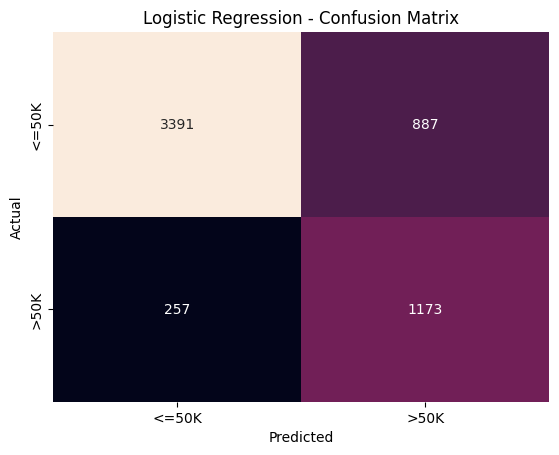


Classification Report:

              precision    recall  f1-score   support

       <=50K       0.93      0.79      0.86      4278
        >50K       0.57      0.82      0.67      1430

    accuracy                           0.80      5708
   macro avg       0.75      0.81      0.76      5708
weighted avg       0.84      0.80      0.81      5708

ROC-AUC: 0.8955724850184879


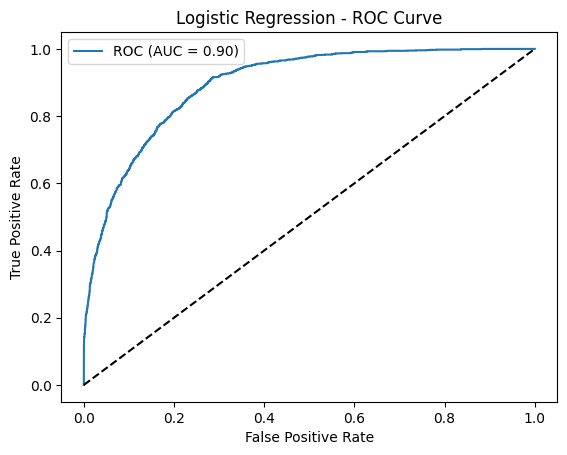

PR AUC: 0.7546597934744997


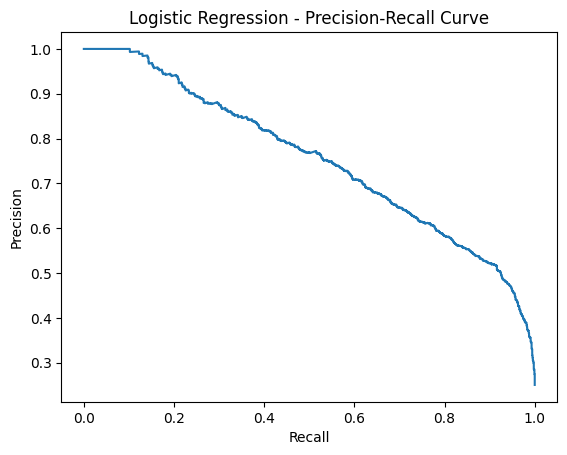

  8%|▊         | 1/12 [00:00<00:04,  2.35it/s]


KNN Confusion Matrix:
 [[3856  422]
 [ 565  865]]


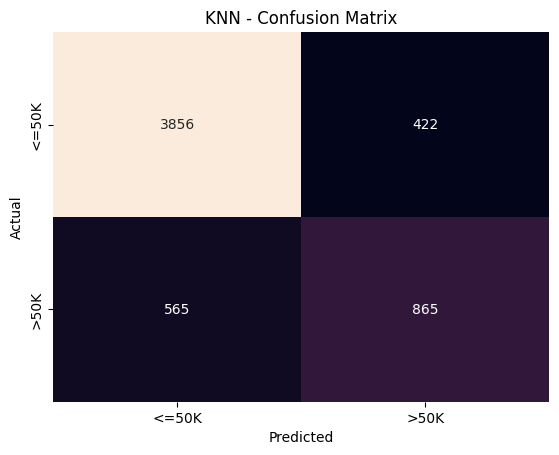


Classification Report:

              precision    recall  f1-score   support

       <=50K       0.87      0.90      0.89      4278
        >50K       0.67      0.60      0.64      1430

    accuracy                           0.83      5708
   macro avg       0.77      0.75      0.76      5708
weighted avg       0.82      0.83      0.82      5708

ROC-AUC: 0.8597487715650409


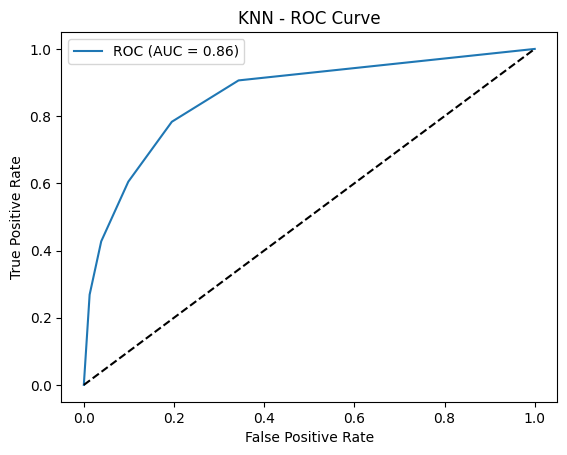

PR AUC: 0.6626014064047415


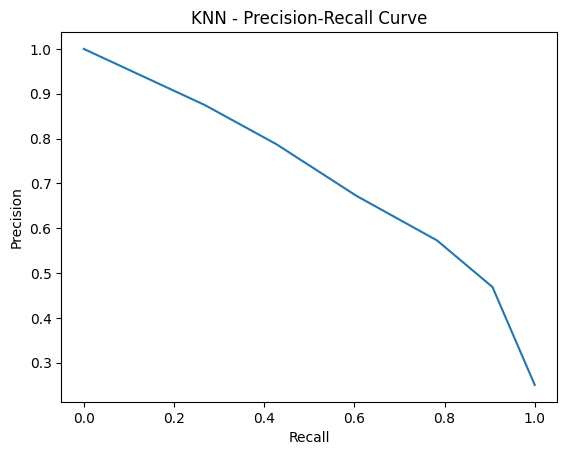

 17%|█▋        | 2/12 [00:07<00:44,  4.49s/it]


Decision Tree Confusion Matrix:
 [[3621  657]
 [ 503  927]]


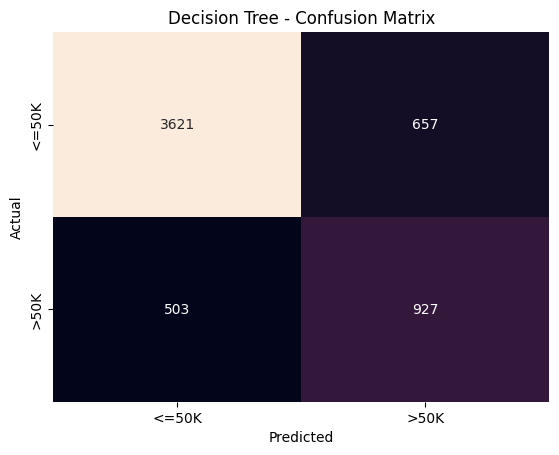


Classification Report:

              precision    recall  f1-score   support

       <=50K       0.88      0.85      0.86      4278
        >50K       0.59      0.65      0.62      1430

    accuracy                           0.80      5708
   macro avg       0.73      0.75      0.74      5708
weighted avg       0.80      0.80      0.80      5708

ROC-AUC: 0.7536289913919647


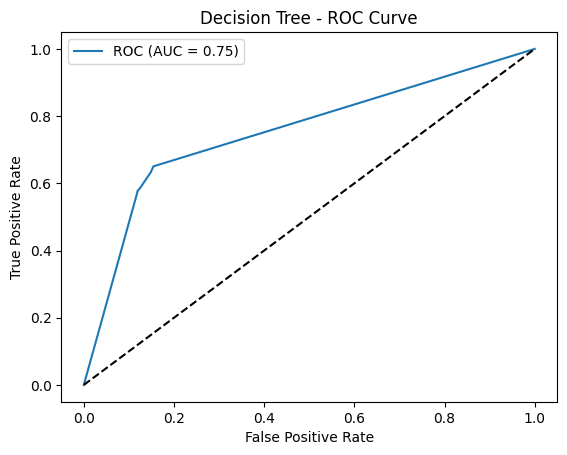

PR AUC: 0.487089136143366


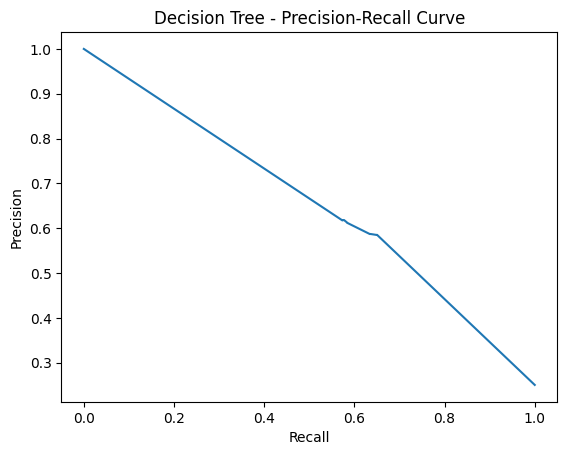

 25%|██▌       | 3/12 [00:08<00:24,  2.73s/it]


Naive Bayes Confusion Matrix:
 [[3904  374]
 [ 613  817]]


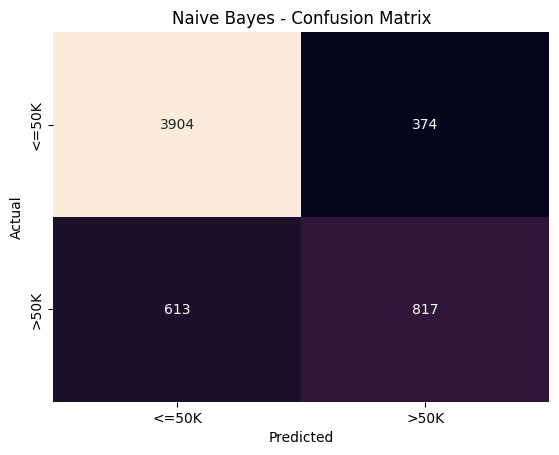


Classification Report:

              precision    recall  f1-score   support

       <=50K       0.86      0.91      0.89      4278
        >50K       0.69      0.57      0.62      1430

    accuracy                           0.83      5708
   macro avg       0.78      0.74      0.76      5708
weighted avg       0.82      0.83      0.82      5708

ROC-AUC: 0.8683146330060777


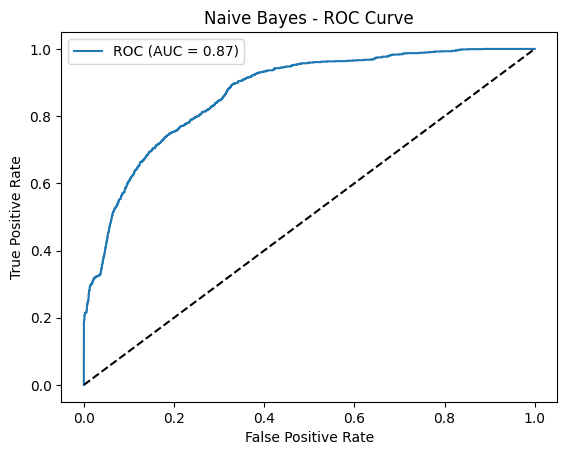

PR AUC: 0.7192653867277335


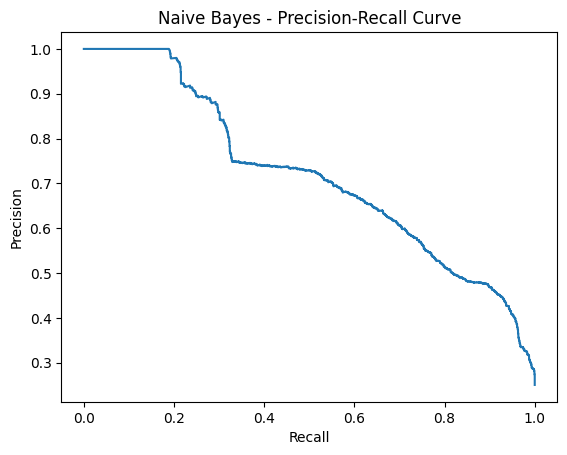

 33%|███▎      | 4/12 [00:09<00:15,  1.92s/it]


Random Forest Confusion Matrix:
 [[3812  466]
 [ 509  921]]


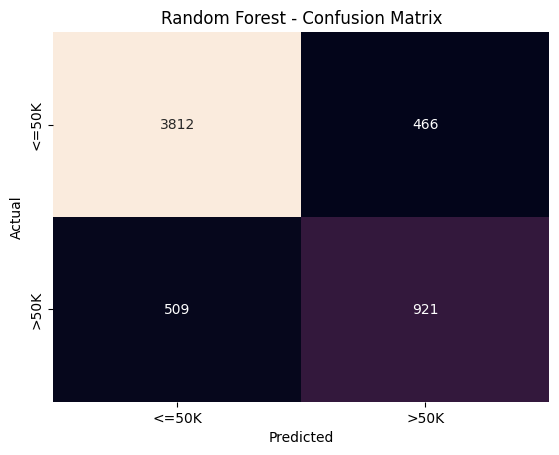


Classification Report:

              precision    recall  f1-score   support

       <=50K       0.88      0.89      0.89      4278
        >50K       0.66      0.64      0.65      1430

    accuracy                           0.83      5708
   macro avg       0.77      0.77      0.77      5708
weighted avg       0.83      0.83      0.83      5708

ROC-AUC: 0.8817724117864372


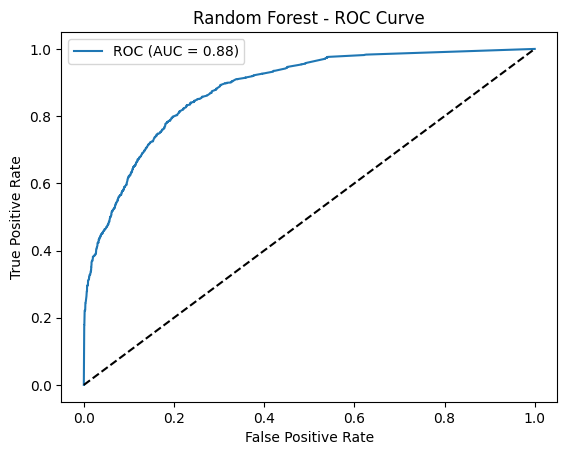

PR AUC: 0.7469266519452534


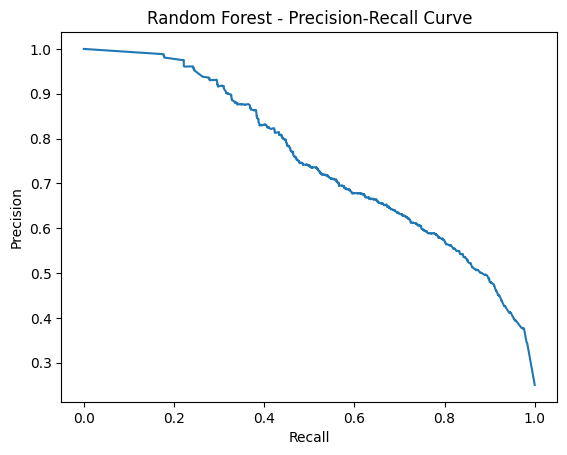

 42%|████▏     | 5/12 [00:12<00:17,  2.57s/it]


Extra Trees Confusion Matrix:
 [[3750  528]
 [ 503  927]]


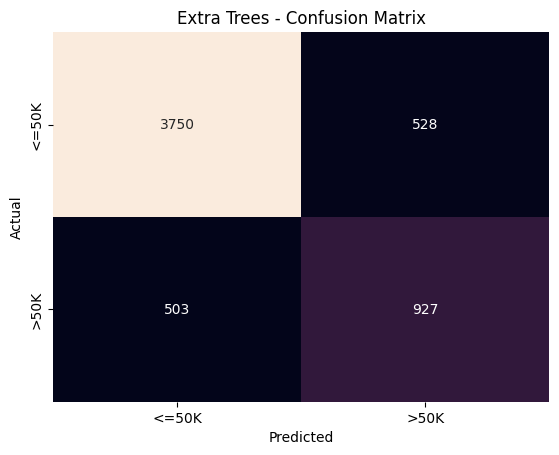


Classification Report:

              precision    recall  f1-score   support

       <=50K       0.88      0.88      0.88      4278
        >50K       0.64      0.65      0.64      1430

    accuracy                           0.82      5708
   macro avg       0.76      0.76      0.76      5708
weighted avg       0.82      0.82      0.82      5708

ROC-AUC: 0.829683663694884


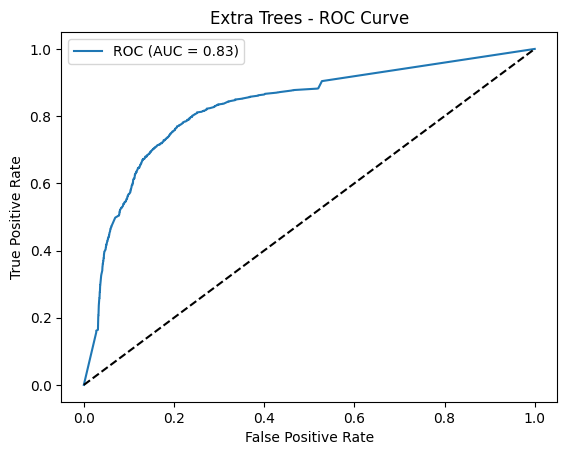

PR AUC: 0.6054670492099372


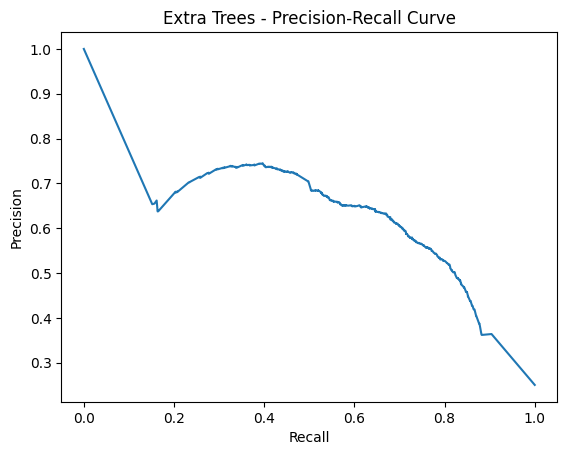

 50%|█████     | 6/12 [00:15<00:16,  2.74s/it]


AdaBoost Confusion Matrix:
 [[4020  258]
 [ 612  818]]


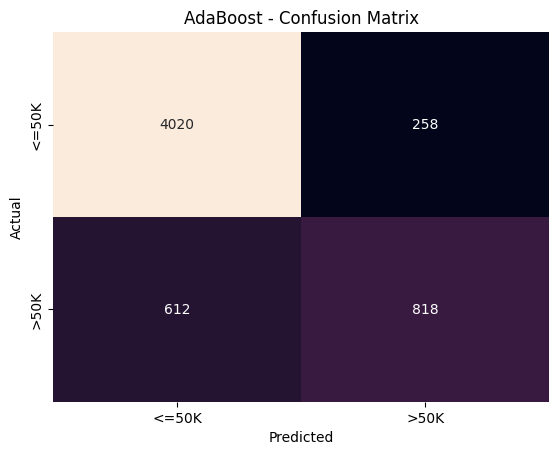


Classification Report:

              precision    recall  f1-score   support

       <=50K       0.87      0.94      0.90      4278
        >50K       0.76      0.57      0.65      1430

    accuracy                           0.85      5708
   macro avg       0.81      0.76      0.78      5708
weighted avg       0.84      0.85      0.84      5708

ROC-AUC: 0.9014535254366952


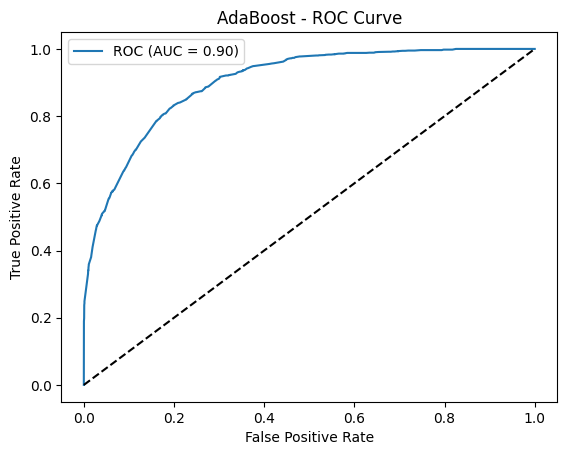

PR AUC: 0.7782891344539199


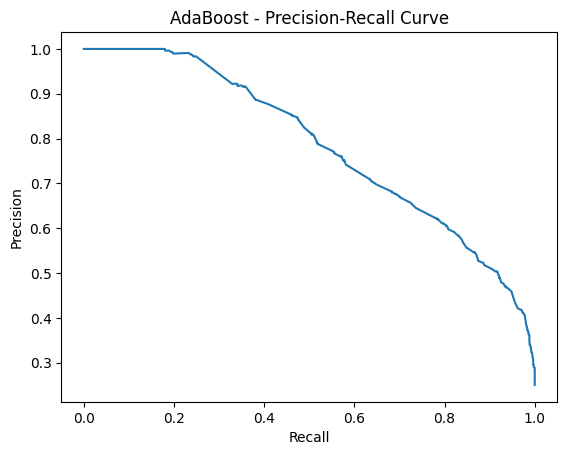

 58%|█████▊    | 7/12 [00:17<00:11,  2.23s/it]


Gradient Boosting Confusion Matrix:
 [[4037  241]
 [ 547  883]]


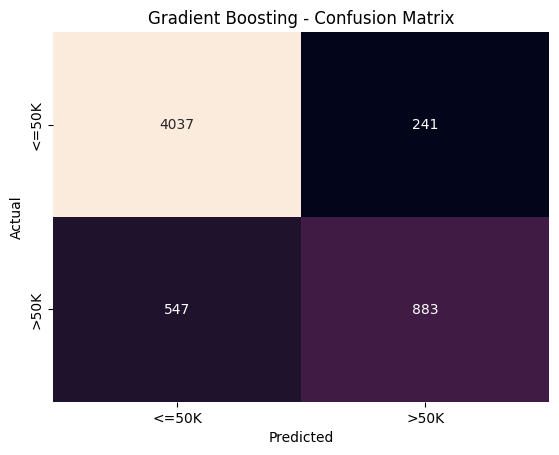


Classification Report:

              precision    recall  f1-score   support

       <=50K       0.88      0.94      0.91      4278
        >50K       0.79      0.62      0.69      1430

    accuracy                           0.86      5708
   macro avg       0.83      0.78      0.80      5708
weighted avg       0.86      0.86      0.86      5708

ROC-AUC: 0.9185116893391788


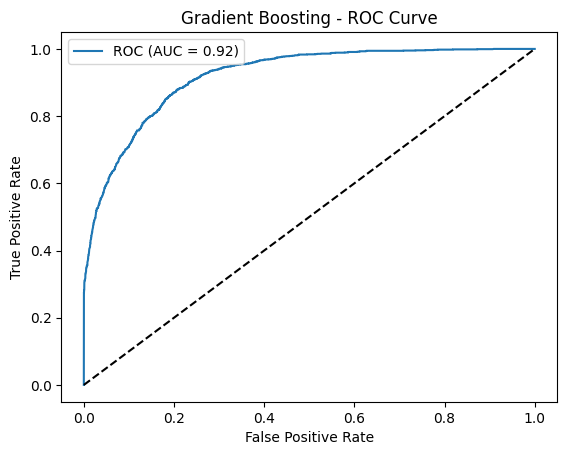

PR AUC: 0.8189939657188481


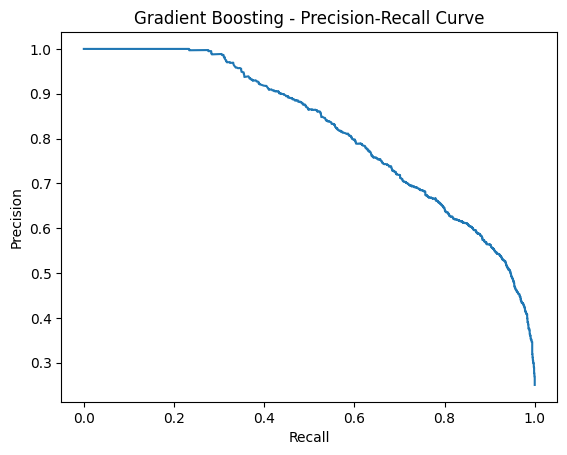

 67%|██████▋   | 8/12 [00:19<00:09,  2.26s/it]


Hist Gradient Boosting Confusion Matrix:
 [[3512  766]
 [ 198 1232]]


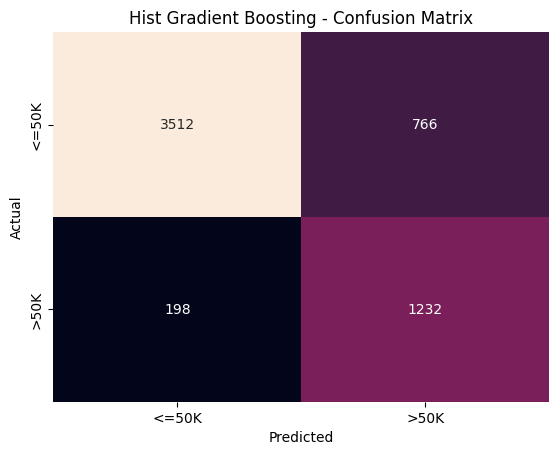


Classification Report:

              precision    recall  f1-score   support

       <=50K       0.95      0.82      0.88      4278
        >50K       0.62      0.86      0.72      1430

    accuracy                           0.83      5708
   macro avg       0.78      0.84      0.80      5708
weighted avg       0.86      0.83      0.84      5708

ROC-AUC: 0.9230284558825935


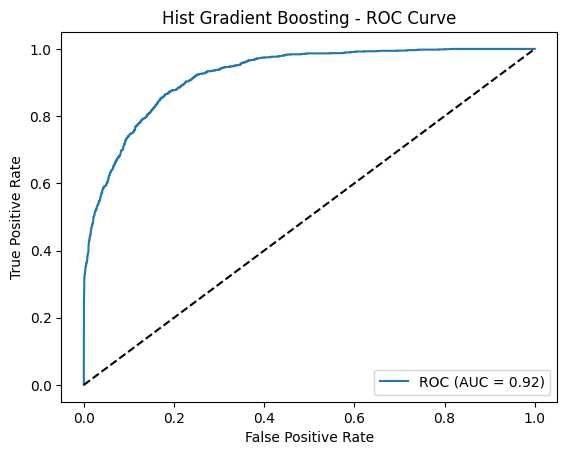

PR AUC: 0.8281281775269637


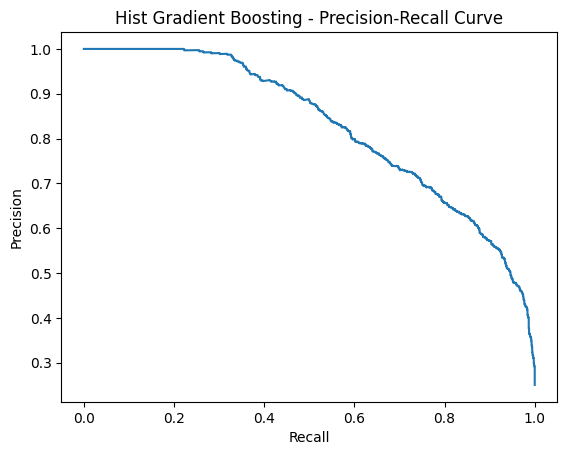

 75%|███████▌  | 9/12 [00:22<00:07,  2.48s/it]


XGBoost Confusion Matrix:
 [[3499  779]
 [ 218 1212]]


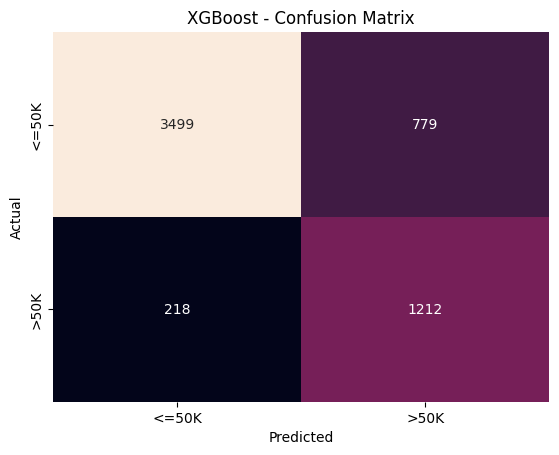


Classification Report:

              precision    recall  f1-score   support

       <=50K       0.94      0.82      0.88      4278
        >50K       0.61      0.85      0.71      1430

    accuracy                           0.83      5708
   macro avg       0.78      0.83      0.79      5708
weighted avg       0.86      0.83      0.83      5708

ROC-AUC: 0.9215343095427247


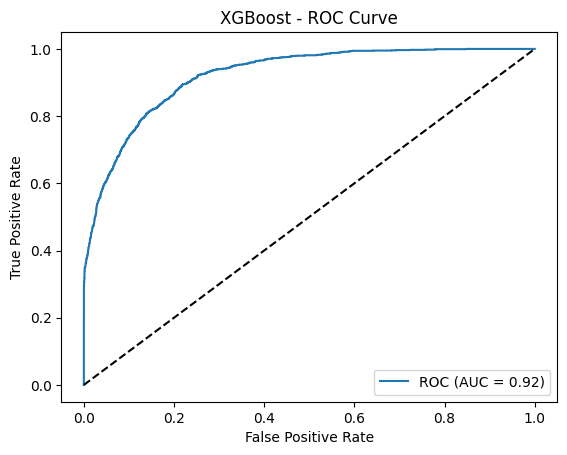

PR AUC: 0.8272973950150528


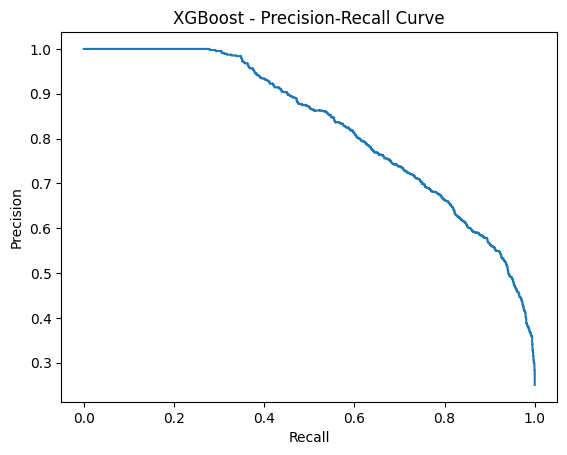

 83%|████████▎ | 10/12 [00:24<00:04,  2.42s/it]


CatBoost Confusion Matrix:
 [[3516  762]
 [ 200 1230]]


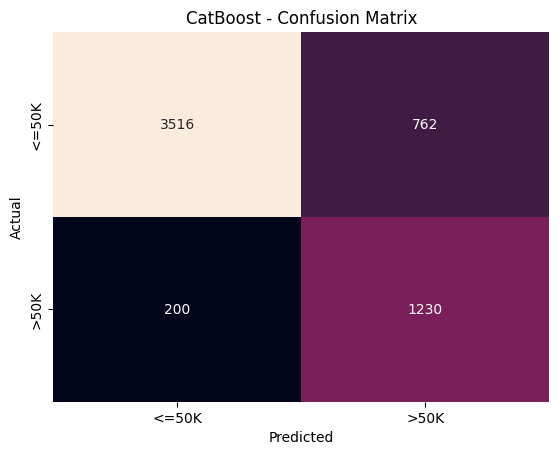


Classification Report:

              precision    recall  f1-score   support

       <=50K       0.95      0.82      0.88      4278
        >50K       0.62      0.86      0.72      1430

    accuracy                           0.83      5708
   macro avg       0.78      0.84      0.80      5708
weighted avg       0.86      0.83      0.84      5708

ROC-AUC: 0.9235387917365477


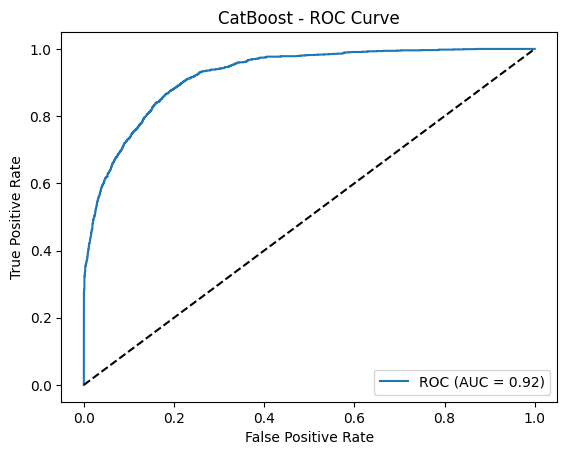

PR AUC: 0.8301839651382314


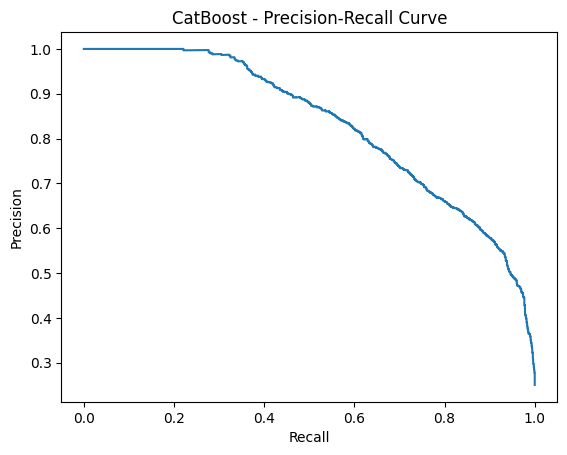

 92%|█████████▏| 11/12 [00:36<00:05,  5.35s/it]

[LightGBM] [Info] Number of positive: 5719, number of negative: 17112
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004394 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 543
[LightGBM] [Info] Number of data points in the train set: 22831, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000

LightGBM Confusion Matrix:
 [[3507  771]
 [ 211 1219]]


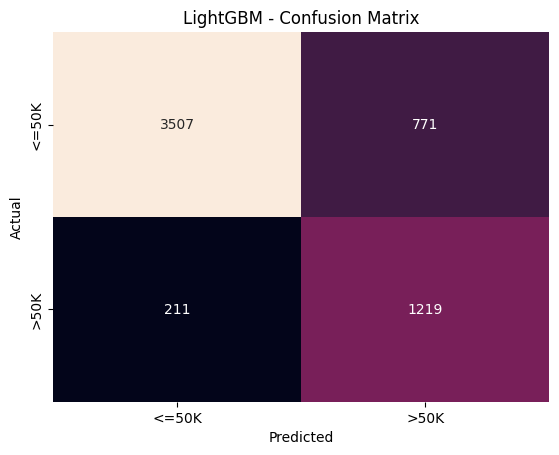


Classification Report:

              precision    recall  f1-score   support

       <=50K       0.94      0.82      0.88      4278
        >50K       0.61      0.85      0.71      1430

    accuracy                           0.83      5708
   macro avg       0.78      0.84      0.80      5708
weighted avg       0.86      0.83      0.84      5708

ROC-AUC: 0.9240581998646515


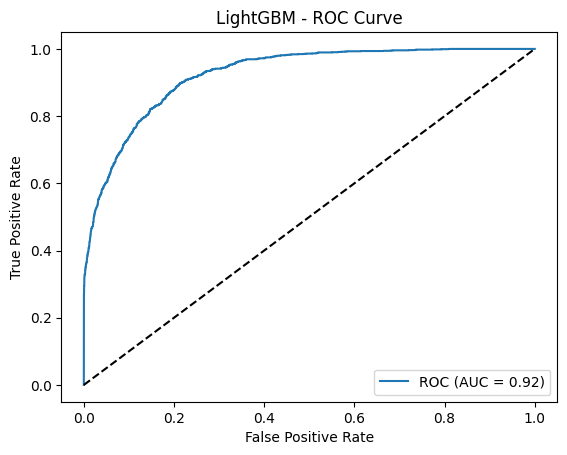

PR AUC: 0.829321662172353


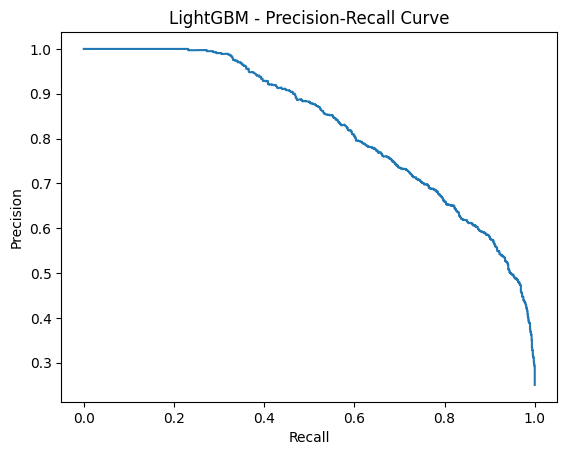

100%|██████████| 12/12 [00:37<00:00,  3.13s/it]


In [75]:
results = {}
for name, model in tqdm(models.items()):
    model.fit(X_train_fs, y_train)
    train_pred = model.predict(X_train_fs)
    test_pred = model.predict(X_test_fs)
    results[name] = {
        "Train Accuracy": accuracy_score(y_train, train_pred),
        "Test Accuracy": accuracy_score(y_test, test_pred),
        "Train Precision": precision_score(y_train, train_pred),
        "Test Precision": precision_score(y_test, test_pred),
        "Train Recall": recall_score(y_train, train_pred),
        "Test Recall": recall_score(y_test, test_pred),
        "Train F1 Score": f1_score(y_train, train_pred),
        "Test F1 Score": f1_score(y_test, test_pred),
        "Train Balanced Accuracy": balanced_accuracy_score(y_train, train_pred),
        "Test Balanced Accuracy": balanced_accuracy_score(y_test, test_pred)
    }
    cm = confusion_matrix(y_test, test_pred)
    print(f"\n{name} Confusion Matrix:\n", cm)
    plt.figure()
    sns.heatmap(cm, annot=True, fmt="d", cbar=False,
                xticklabels=['<=50K', '>50K'],
                yticklabels=['<=50K', '>50K'])
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.title(f'{name} - Confusion Matrix')
    plt.show()
    print("\nClassification Report:\n")
    print(classification_report(y_test, test_pred,
                                target_names=['<=50K', '>50K'],
                                zero_division=0))
    if hasattr(model, "predict_proba"):
        y_pred_prob = model.predict_proba(X_test_fs)[:, 1]
        roc_auc = roc_auc_score(y_test, y_pred_prob)
        print("ROC-AUC:", roc_auc)
        fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
        plt.figure()
        plt.plot(fpr, tpr, label=f'ROC (AUC = {roc_auc:.2f})')
        plt.plot([0, 1], [0, 1], 'k--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'{name} - ROC Curve')
        plt.legend()
        plt.show()
        pr_auc = average_precision_score(y_test, y_pred_prob)
        print("PR AUC:", pr_auc)
        precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_pred_prob)
        plt.figure()
        plt.plot(recall_vals, precision_vals)
        plt.xlabel('Recall')
        plt.ylabel('Precision')
        plt.title(f'{name} - Precision-Recall Curve')
        plt.show()

**Interpretation:** Every model is fit once on `X_train_fs`/`y_train` and evaluated on both splits, with a confusion matrix, full classification report, and (where supported) an ROC and precision-recall curve — giving a consistent, multi-metric view of each model's baseline performance before any tuning.

In [76]:
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values(by="Test F1 Score", ascending=False)
results_df

,Train Accuracy,Test Accuracy,Train Precision,Test Precision,Train Recall,Test Recall,Train F1 Score,Test F1 Score,Train Balanced Accuracy,Test Balanced Accuracy
CatBoost,0.854759,0.831465,0.651380,0.617470,0.904004,0.860140,0.757176,0.718878,0.871152,0.841010
Hist Gradient Boosting,0.843590,0.831114,0.633715,0.616617,0.890016,0.861538,0.740310,0.718786,0.859045,0.841241
LightGBM,0.846130,0.827961,0.638082,0.612563,0.891240,0.852448,0.743708,0.712865,0.861147,0.836112
XGBoost,0.861197,0.825333,0.660498,0.608739,0.917468,0.847552,0.768060,0.708565,0.879930,0.832729
Gradient Boosting,0.863957,0.861948,0.787459,0.785587,0.625809,0.617483,0.697389,0.691464,0.784679,0.780574
Logistic Regression,0.798125,0.799580,0.566451,0.569417,0.827243,0.820280,0.672447,0.672206,0.807818,0.806470
Random Forest,0.967369,0.829187,0.898047,0.664023,0.981116,0.644056,0.937745,0.653887,0.971945,0.767563
AdaBoost,0.847225,0.847582,0.766420,0.760223,0.561112,0.572028,0.647890,0.652833,0.751980,0.755860
Extra Trees,0.964303,0.819376,0.876651,0.637113,0.997902,0.648252,0.933355,0.642634,0.975488,0.762415
KNN,0.877141,0.827085,0.784348,0.672106,0.702745,0.604895,0.741308,0.636732,0.819085,0.753125


**Interpretation:** Sorting all trained models by Test F1 Score (a better single summary than accuracy for an imbalanced target) gives a first ranking of baseline model performance, alongside Train F1 (to spot overfitting when the train score is much higher than the test score).

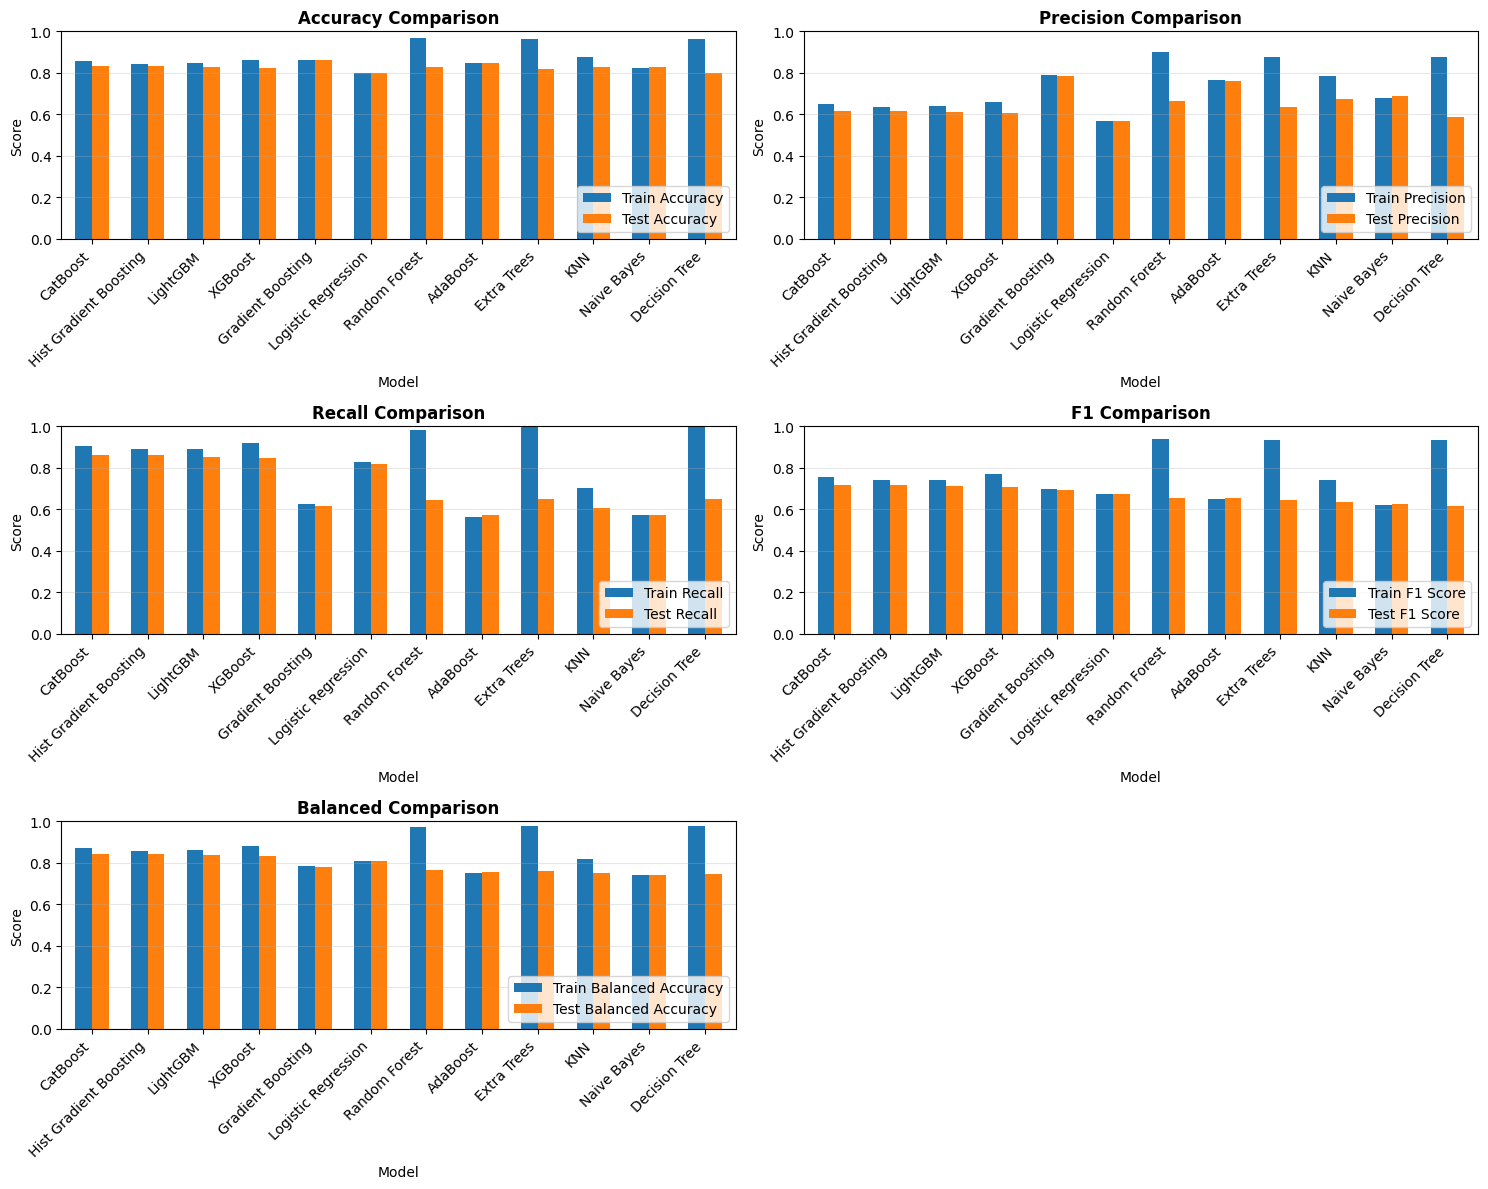

In [77]:
cols = [
    ['Train Accuracy', 'Test Accuracy'],
    ['Train Precision', 'Test Precision'],
    ['Train Recall', 'Test Recall'],
    ['Train F1 Score', 'Test F1 Score'],
    ["Train Balanced Accuracy", "Test Balanced Accuracy"]
]

plt.figure(figsize=(15, 12))

for i, col in enumerate(cols):
    ax = plt.subplot(3, 2, i+1)

    results_df[col].plot.bar(ax=ax, width=0.6)

    ax.set_title(col[0].split(" ")[1] + ' Comparison', fontsize=12, fontweight='bold')
    ax.set_xlabel('Model', fontsize=10)
    ax.set_ylabel('Score', fontsize=10)
    ax.set_ylim(0, 1)
    ax.grid(axis='y', alpha=0.3)
    ax.legend(loc='lower right')

    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

**Interpretation:** Plotting Train vs. Test side by side for every metric makes overfitting easy to spot at a glance — the tree-based models with no depth limit show the largest train/test gaps, while the boosting models and Logistic Regression generalize more consistently.

### 11.1 Cross-Validation (all baseline models, on selected features)

In [78]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)
cv_results = {}
for name, model in tqdm(models.items()):
    fold_f1_scores = []
    for train_idx, val_idx in cv.split(X_train, y_train):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        fold_selector = SelectKBest(score_func=mi_score_func, k=k_best)
        fold_selector.fit(X_tr, y_tr)
        X_tr_sel = fold_selector.transform(X_tr)
        X_val_sel = fold_selector.transform(X_val)

        fold_model = clone(model)
        fold_model.fit(X_tr_sel, y_tr)
        val_pred = fold_model.predict(X_val_sel)
        fold_f1_scores.append(f1_score(y_val, val_pred))

    fold_f1_scores = np.array(fold_f1_scores)
    cv_results[name] = {
        "CV F1 Mean": fold_f1_scores.mean(),
        "CV F1 Std": fold_f1_scores.std()
    }

cv_results_df = pd.DataFrame(cv_results).T.sort_values(by="CV F1 Mean", ascending=False)
cv_results_df

 92%|█████████▏| 11/12 [04:11<00:33, 33.86s/it]

[LightGBM] [Info] Number of positive: 4575, number of negative: 13689
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000895 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 529
[LightGBM] [Info] Number of data points in the train set: 18264, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


d:\saifproject\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 4576, number of negative: 13689
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000780 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 513
[LightGBM] [Info] Number of data points in the train set: 18265, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


d:\saifproject\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


...

[LightGBM] [Info] Number of positive: 4575, number of negative: 13690
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000965 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 522
[LightGBM] [Info] Number of data points in the train set: 18265, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


d:\saifproject\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 4575, number of negative: 13690
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000862 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 525
[LightGBM] [Info] Number of data points in the train set: 18265, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


d:\saifproject\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
100%|██████████| 12/12 [04:26<00:00, 22.22s/it]


,CV F1 Mean,CV F1 Std
Hist Gradient Boosting,0.721243,0.007074
LightGBM,0.719969,0.005329
CatBoost,0.719502,0.004304
XGBoost,0.718006,0.005668
Gradient Boosting,0.688864,0.010730
Logistic Regression,0.674794,0.006897
AdaBoost,0.652461,0.004742
Random Forest,0.648664,0.008520
Extra Trees,0.634788,0.009678
KNN,0.633441,0.008793


**Interpretation:** Re-running `SelectKBest` inside each cross-validation fold (rather than reusing the single fit from Section 10) avoids any leakage of validation-fold information into feature selection, giving a more robust 5-fold F1 estimate for each model than the single train/test split above.

In [79]:
top3_names = cv_results_df.head(3).index.tolist()
print("Best 3 models by Cross-Validation F1 Score:")
for i, name in enumerate(top3_names, 1):
    print(f"{i}. {name}  (CV F1 = {cv_results_df.loc[name, 'CV F1 Mean']:.4f})")

Best 3 models by Cross-Validation F1 Score:
1. Hist Gradient Boosting  (CV F1 = 0.7212)
2. LightGBM  (CV F1 = 0.7200)
3. CatBoost  (CV F1 = 0.7195)


**Interpretation:** The top 3 models by cross-validated F1 are carried forward into hyperparameter tuning below, rather than tuning all 12 models — a practical trade-off between thoroughness and compute time.

### 11.2 Grid Search on the Best 3 Models

In [80]:
param_grids_all = {
    "XGBoost": {
        "n_estimators": [100, 200],
        "max_depth": [3, 5],
        "learning_rate": [0.05, 0.1],
        "subsample": [0.8, 1.0]
    },
    "LightGBM": {
        "n_estimators": [100, 200],
        "max_depth": [-1, 5],
        "learning_rate": [0.05, 0.1],
        "num_leaves": [31, 50]
    },
    "CatBoost": {
        "iterations": [100, 200],
        "depth": [4, 6],
        "learning_rate": [0.05, 0.1],
        "l2_leaf_reg": [3, 5]
    },
    "Hist Gradient Boosting": {
        "max_iter": [100, 200],
        "max_depth": [None, 5, 10],
        "learning_rate": [0.05, 0.1],
        "l2_regularization": [0.0, 1.0]
    },
    "Gradient Boosting": {
        "n_estimators": [100, 200],
        "max_depth": [3, 5],
        "learning_rate": [0.05, 0.1]
    },
    "Random Forest": {
        "n_estimators": [100, 200],
        "max_depth": [None, 10, 20],
        "min_samples_split": [2, 5]
    },
    "Extra Trees": {
        "n_estimators": [100, 200],
        "max_depth": [None, 10, 20],
        "min_samples_split": [2, 5]
    },
    "AdaBoost": {
        "n_estimators": [50, 100],
        "learning_rate": [0.5, 1.0]
    },
    "Logistic Regression": {
        "C": [0.01, 0.1, 1, 10]
    },
    "KNN": {
        "n_neighbors": [3, 5, 7, 9]
    },
    "Decision Tree": {
        "max_depth": [None, 5, 10, 20],
        "min_samples_split": [2, 5, 10]
    },
    "Naive Bayes": {}
}

scorer = make_scorer(f1_score)
tuned_models = {}
tuned_results = []

for name in top3_names:
    print(f"Running GridSearchCV for {name} ...")
    base_model = models[name]
    grid_params = param_grids_all.get(name, {})

    if not grid_params:
        best_model = base_model.fit(X_train_fs, y_train)
        best_params = {}
    else:
        grid = GridSearchCV(
            estimator=base_model,
            param_grid=grid_params,
            scoring=scorer,
            cv=cv,
            n_jobs=-1
        )
        grid.fit(X_train_fs, y_train)
        best_model = grid.best_estimator_
        best_params = grid.best_params_

    tuned_models[name] = best_model

    train_pred = best_model.predict(X_train_fs)
    test_pred = best_model.predict(X_test_fs)

    tuned_results.append({
        "Model": name,
        "Best Params": best_params,
        "Train F1": f1_score(y_train, train_pred),
        "Test F1": f1_score(y_test, test_pred),
        "Test Accuracy": accuracy_score(y_test, test_pred),
        "Test Balanced Accuracy": balanced_accuracy_score(y_test, test_pred)
    })

tuned_results_df = pd.DataFrame(tuned_results).sort_values(
    by="Test F1", ascending=False
).reset_index(drop=True)

tuned_results_df

Running GridSearchCV for Hist Gradient Boosting ...
Running GridSearchCV for LightGBM ...
[LightGBM] [Info] Number of positive: 5719, number of negative: 17112
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.023175 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 543
[LightGBM] [Info] Number of data points in the train set: 22831, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
Running GridSearchCV for CatBoost ...


,Model,Best Params,Train F1,Test F1,Test Accuracy,Test Balanced Accuracy
0,Hist Gradient Boosting,"{'l2_regularization': 0.0, 'learning_rate': 0....",0.741729,0.722467,0.834443,0.842997
1,CatBoost,"{'depth': 4, 'iterations': 200, 'l2_leaf_reg':...",0.727918,0.717695,0.830063,0.840773
2,LightGBM,"{'learning_rate': 0.05, 'max_depth': -1, 'n_es...",0.742662,0.715286,0.829012,0.838442


**Interpretation:** `GridSearchCV` (scored on F1, using the same stratified CV splitter as above) is run only for the top 3 models, searching a small but targeted hyperparameter grid for each. The resulting `tuned_models` dictionary holds the best estimator found for each of the three, ready to feed into stacking below.

### 11.3 Stacking the Best 3 Models

In [81]:
estimators = [(name.replace(" ", "_"), tuned_models[name]) for name in top3_names]

stacking_model = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(max_iter=2000, random_state=1),
    cv=5,
    n_jobs=-1
)

stacking_model.fit(X_train_fs, y_train)

stack_train_pred = stacking_model.predict(X_train_fs)
stack_test_pred = stacking_model.predict(X_test_fs)

stack_result = {
    "Model": f"Stacking ({' + '.join(top3_names)})",
    "Best Params": "-",
    "Train F1": f1_score(y_train, stack_train_pred),
    "Test F1": f1_score(y_test, stack_test_pred),
    "Test Accuracy": accuracy_score(y_test, stack_test_pred),
    "Test Balanced Accuracy": balanced_accuracy_score(y_test, stack_test_pred)
}

print(classification_report(y_test, stack_test_pred, target_names=['<=50K', '>50K']))
stack_result

              precision    recall  f1-score   support

       <=50K       0.91      0.90      0.91      4278
        >50K       0.71      0.73      0.72      1430

    accuracy                           0.86      5708
   macro avg       0.81      0.82      0.82      5708
weighted avg       0.86      0.86      0.86      5708



{'Model': 'Stacking (Hist Gradient Boosting + LightGBM + CatBoost)',
 'Best Params': '-',
 'Train F1': 0.7427041961664652,
 'Test F1': 0.724577731816615,
 'Test Accuracy': 0.8600210231254379,
 'Test Balanced Accuracy': 0.8183941584362342}

**Interpretation:** A `StackingClassifier` combines the 3 tuned models as base learners with a Logistic Regression meta-model, aiming to combine their complementary strengths into a single, typically more accurate, prediction.

## 12. Model Evaluation

In [82]:
final_comparison = pd.concat(
    [tuned_results_df, pd.DataFrame([stack_result])],
    ignore_index=True
).sort_values(by="Test F1", ascending=False).reset_index(drop=True)

print(final_comparison[["Model", "Train F1", "Test F1", "Test Accuracy", "Test Balanced Accuracy"]].to_string(index=False))

best_row = final_comparison.iloc[0]
best_model_name = best_row["Model"]

print(f"\nBest overall model: {best_model_name}")
print(f"Test F1 Score: {best_row['Test F1']:.4f}")
print(f"Test Accuracy: {best_row['Test Accuracy']:.4f}")
print(f"Test Balanced Accuracy: {best_row['Test Balanced Accuracy']:.4f}")

                                                  Model  Train F1  Test F1  Test Accuracy  Test Balanced Accuracy
Stacking (Hist Gradient Boosting + LightGBM + CatBoost)  0.742704 0.724578       0.860021                0.818394
                                 Hist Gradient Boosting  0.741729 0.722467       0.834443                0.842997
                                               CatBoost  0.727918 0.717695       0.830063                0.840773
                                               LightGBM  0.742662 0.715286       0.829012                0.838442

Best overall model: Stacking (Hist Gradient Boosting + LightGBM + CatBoost)
Test F1 Score: 0.7246
Test Accuracy: 0.8600
Test Balanced Accuracy: 0.8184


**Interpretation:** The final comparison table ranks all tuned individual models plus the stacking ensemble by Test F1 / Accuracy / Balanced Accuracy, identifying the best-performing model for predicting `income`.

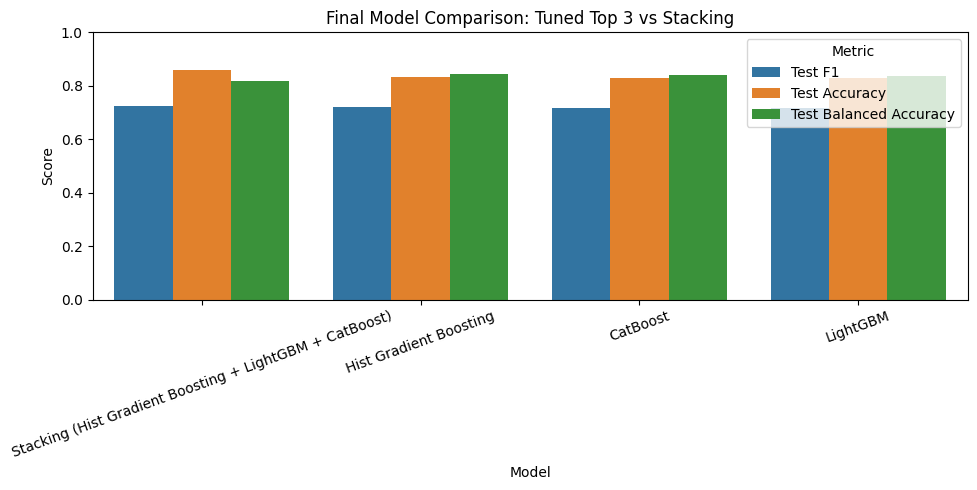

In [83]:
plt.figure(figsize=(10, 5))
plot_df = final_comparison[["Model", "Test F1", "Test Accuracy", "Test Balanced Accuracy"]].melt(
    id_vars="Model", var_name="Metric", value_name="Score"
)
sns.barplot(data=plot_df, x="Model", y="Score", hue="Metric")
plt.title("Final Model Comparison: Tuned Top 3 vs Stacking")
plt.xticks(rotation=20)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

**Interpretation:** This chart visualizes the same ranking as the table above across all three headline metrics at once, making it easy to see whether the stacking ensemble actually improves on the best individual tuned model or simply matches it.

## 13. Save Final Model and Deployment Artifacts

Looking at `final_comparison` (sorted by Test F1), `best_model_name` identifies the best-performing model. Whichever model that turns out to be — a single tuned model or the stacking ensemble — it is saved to disk as `best_model.pkl` below.

In [84]:
best_model_lookup = {**tuned_models, stack_result["Model"]: stacking_model}
best_model = best_model_lookup[best_model_name]
joblib.dump(best_model, "best_model.pkl")
print(f"Saved '{best_model_name}' to best_model.pkl")

Saved 'Stacking (Hist Gradient Boosting + LightGBM + CatBoost)' to best_model.pkl


### 13.1 Consolidated deployment artifacts

All preprocessing objects were already saved with `joblib` immediately after being fit (Section 9), and `selected_features.pkl` was saved right after the final feature set was determined (Section 10). The remaining pieces needed to reconstruct a valid input row — the raw column list and the encoding maps used before the saved encoder objects — are consolidated into a single config file here.

In [85]:
feature_columns_config = {
    "raw_input_columns": raw_input_columns,        # columns a Streamlit form must collect
    "categorical_impute_cols": missing,             # columns the categorical imputer expects
    "ohe_cols": ohe_cols,                           # columns the one-hot encoder expects
    "target_enc_col": "occupation",                 # column the target encoder expects
    "numeric_cols_to_scale": list(num_cols),        # columns the scaler expects
    "selected_features": selected_features,         # final feature order the model expects
}

joblib.dump(feature_columns_config, "feature_columns_config.pkl")
print("Saved feature_columns_config.pkl with keys:", list(feature_columns_config.keys()))

Saved feature_columns_config.pkl with keys: ['raw_input_columns', 'categorical_impute_cols', 'ohe_cols', 'target_enc_col', 'numeric_cols_to_scale', 'selected_features']


### 13.2 Final feature-consistency check against the trained model

A last check ties Section 10's requirements together directly against the fitted `best_model`: the number of features it was trained on must match `len(selected_features)` exactly.

In [86]:
n_expected = getattr(best_model, "n_features_in_", None)
status = "OK" if (n_expected is None or n_expected == len(selected_features)) else "MISMATCH"
print(f"{best_model_name:25s} n_features_in_={n_expected}  expected={len(selected_features)}  [{status}]")

Stacking (Hist Gradient Boosting + LightGBM + CatBoost) n_features_in_=15  expected=15  [OK]


### 13.3 End-to-end deployment simulation (raw input → prediction)

This final test reproduces the *exact* Streamlit inference workflow, starting from one truly raw row re-read from the original CSV (not the in-memory `df`, which has already been mutated throughout this notebook) — exactly as a Streamlit form would hand off one filled-in row.

In [88]:
categorical_imputer_loaded = joblib.load("categorical_imputer.pkl")
sex_encoder_loaded = joblib.load("sex_encoder.pkl")
country_encoder_loaded = joblib.load("native_country_encoder.pkl")
marital_encoder_loaded = joblib.load("marital_status_encoder.pkl")
onehot_encoder_loaded = joblib.load("onehot_encoder.pkl")
occupation_target_encoder_loaded = joblib.load("occupation_target_encoder.pkl")
scaler_loaded = joblib.load("standard_scaler.pkl")
selected_features_loaded = joblib.load("selected_features.pkl")
feature_columns_config_loaded = joblib.load("feature_columns_config.pkl")
best_model_loaded = joblib.load("best_model.pkl")

raw_df = pd.read_csv(r'D:\saifproject\SIC AI\Adult\adult.csv')
raw_row = raw_df.sample(1, random_state=7).copy()
print("Raw sampled row:")
display(raw_row)

sim = apply_basic_cleaning(raw_row, is_training=False)
sim = apply_feature_engineering(sim)

sim[feature_columns_config_loaded["categorical_impute_cols"]] = categorical_imputer_loaded.transform(
    sim[feature_columns_config_loaded["categorical_impute_cols"]]
)

sim['sex'] = sim['sex'].map(sex_encoder_loaded)
sim['native.country'] = sim['native.country'].map(country_encoder_loaded)
sim['marital.status'] = sim['marital.status'].map(marital_encoder_loaded)

ohe_cols_sim = feature_columns_config_loaded["ohe_cols"]
sim_encoded = onehot_encoder_loaded.transform(sim[ohe_cols_sim])
sim_encoded = pd.DataFrame(
    sim_encoded,
    columns=onehot_encoder_loaded.get_feature_names_out(ohe_cols_sim),
    index=sim.index
)
sim = pd.concat([sim.drop(columns=ohe_cols_sim), sim_encoded], axis=1)

sim['occupation'] = occupation_target_encoder_loaded.transform(sim['occupation'])

num_cols_sim = feature_columns_config_loaded["numeric_cols_to_scale"]
sim[num_cols_sim] = scaler_loaded.transform(sim[num_cols_sim])

sim_fs = sim[selected_features_loaded]

prediction = best_model_loaded.predict(sim_fs)[0]
label = ">50K" if prediction == 1 else "<=50K"
print(f"\nActual income label: {raw_row['income'].values[0]}")
print(f"Predicted income:     {label}")

Raw sampled row:


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
18329,68,Private,121846,7th-8th,4,Widowed,Other-service,Unmarried,Amer-Indian-Eskimo,Female,0,0,20,United-States,<=50K



Actual income label: <=50K
Predicted income:     <=50K


**Interpretation:** Starting from a single untouched raw row and replaying every saved artifact in order — `apply_basic_cleaning` → `apply_feature_engineering` → categorical imputer → sex/country/marital-status maps → one-hot encoder → occupation target encoder → scaler → selected-feature subset → model — successfully reproduces a prediction. This confirms the full deployment pipeline is self-consistent and ready to be wrapped in a Streamlit (or any other) app that only needs to collect `raw_input_columns` from the user.

## Summary

- Placeholder `"?"` values were converted to real `NaN`, non-predictive/redundant columns (`fnlwgt`, `education`) were dropped, and high-cardinality categorical columns (`race`, `marital.status`, `workclass`, `native.country`) were consolidated into a smaller, more meaningful set of categories (Section 4).
- EDA showed a right-skewed `capital.gain`/`capital.loss`, an imbalanced target (~76% `<=50K` / 24% `>50K`), and highlighted `education.num`, `marital.status`, `hours.per.week`, and `age` as the strongest visual predictors of income (Section 5).
- One engineered feature, `capital_diff` (net capital gains), was added on top of the cleaned raw signals (Section 6).
- All preprocessing — most-frequent imputation, binary/one-hot/target encoding, and standard scaling — was fit exclusively on the training split and immediately persisted with `joblib` (Section 9).
- Mutual-Information-based `SelectKBest` narrowed the feature set to the 15 most informative columns (Section 10).
- Twelve baseline classifiers were compared, the top 3 by cross-validated F1 were hyperparameter-tuned, and a stacking ensemble of those 3 was built; the best performer by Test F1 was selected as the final model (Sections 11–12).
- All deployment artifacts (imputer, encoders, scaler, selected feature list, and the final model) were saved and verified end-to-end against one truly raw input row, confirming the pipeline is ready to be wrapped in a deployment app (Section 13).